## expxx

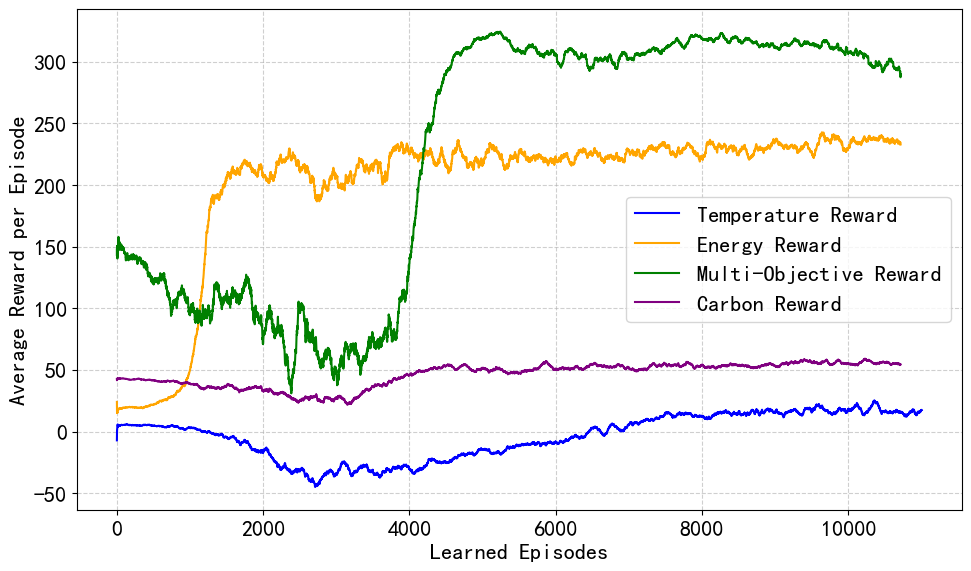

In [ ]:

import os
import json
import matplotlib.pyplot as plt

# 设置全局字体大小
plt.rcParams['font.size'] = 16
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# === 统一读取数据 ===
# DQN- Ta
Ta_dqn_ep_rew_mean = []
Ta_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250723 V1 Ta reward", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                Ta_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                Ta_dqn_episodes.append(data["time/episodes"])
                
# DQN Ca
Ca_dqn_ep_rew_mean = []
Ca_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250723 V1 Ca reward", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                Ca_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                Ca_dqn_episodes.append(data["time/episodes"])
            else:
                print("缺少数据")
                
# DQN energy
energy_dqn_ep_rew_mean = []
energy_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250723 V1 energy reward", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                energy_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                energy_dqn_episodes.append(data["time/episodes"])
            else:
                print("缺少数据")
                
# DQN multi obj
multi_obj_dqn_ep_rew_mean = []
multi_obj_dqn_episodes = []
with open(os.path.join(rf"data\compare_data\250724 V1 weight_three_obj_over", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                multi_obj_dqn_ep_rew_mean.append(data["rollout/ep_rew_mean"])
                multi_obj_dqn_episodes.append(data["time/episodes"])

# 绘制 Reward
plt.figure(figsize=(10, 6))

plt.plot(Ta_dqn_episodes, Ta_dqn_ep_rew_mean, label="Temperature Reward", color='blue')
# plt.plot(energy_dqn_episodes, energy_dqn_ep_rew_mean, label="Energy Reward", color='red')
plt.plot(e11_dqn_episodes, e11_dqn_ep_rew_mean, label="Energy Reward", color='orange')
plt.plot(multi_obj_dqn_episodes, multi_obj_dqn_ep_rew_mean, label="Multi-Objective Reward", color='green')
plt.plot(Ca_dqn_episodes, Ca_dqn_ep_rew_mean, label="Carbon Reward", color='purple')
plt.xlabel("Learned Episodes")
plt.ylabel("Average Reward per Episode")
# plt.legend(frameon=False)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



### 训练结果绘制

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

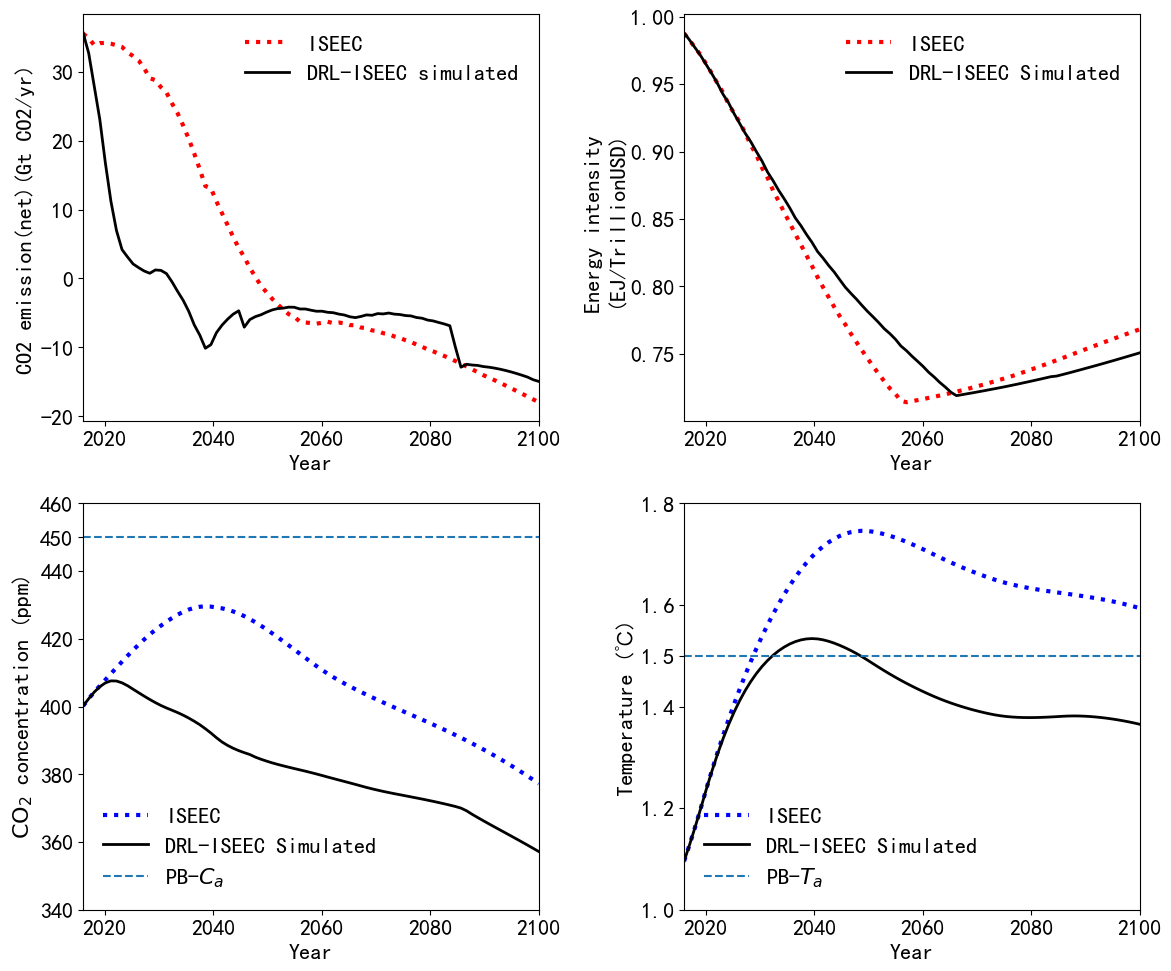

In [74]:
# 绘制 state(share of renewable energy/co2 net emission co2 concentration/temperature)
# 读取 data 里面 compare_data 里面的相关数据进行比较绘制

from cProfile import label
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

# 设置全局字体大小
plt.rcParams['font.size'] = 16

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

custom_reward_type = "weight_three_obj_over_same"
env = IEMEnv(reward_type=custom_reward_type)

# 读取第一维度数据:iseec-default
df_83_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第二维度数据 sameweights 最新结果
df_83_type2 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")
df_251_type2 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

years = np.linspace(2016, 2100, 83)

# states_type1 = np.array(total_state_type1)
T_a_type1 = df_83_type1['T_a']
C_a_type1 = df_83_type1['C_a']

E21_type1 = df_83_type1['E21']
E22_type1 = df_83_type1['E22']
E23_type1 = df_83_type1['E23']
E24_type1 = df_83_type1['E24']
E12_type1 = df_83_type1['E12']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1 = df_251_type1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated_type1 = df_251_type1['energy_MYbaseline18502100_total_formulated']

E11_type1 = (
    energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:]
    - E21_type1
    - E22_type1
    - E23_type1
    - E24_type1
    - E12_type1
)

CO2emission_actualFF_type1 = df_251_type1['CO2emission_actualFF']
CO2emission_ACE1_type1 = df_251_type1['CO2emission_ACE1']
CO2emission_ACE2_type1 = df_251_type1['CO2emission_ACE2']
CO2emission_ACE3_type1 = df_251_type1['CO2emission_ACE3']
ratio_net_over_gross_type1 = df_251_type1['ratio_net_over_gross']
re_type1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1, 
        energy_MYbaseline18502100_total_formulated_type1
    )
][-83:]

T_a_type2 = df_83_type2['T_a']
C_a_type2 = df_83_type2['C_a']

E21_type2 = df_83_type2['E21']
E22_type2 = df_83_type2['E22']
E23_type2 = df_83_type2['E23']
E24_type2 = df_83_type2['E24']
E12_type2 = df_83_type2['E12']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2 = df_251_type2['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated_type2 = df_251_type2['energy_MYbaseline18502100_total_formulated']

E11_type2 = (
    energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:]
    - E21_type2
    - E22_type2
    - E23_type2
    - E24_type2
    - E12_type2
)

CO2emission_actualFF_type2 = df_251_type2['CO2emission_actualFF']
CO2emission_ACE1_type2 = df_251_type2['CO2emission_ACE1']
CO2emission_ACE2_type2 = df_251_type2['CO2emission_ACE2']
CO2emission_ACE3_type2 = df_251_type2['CO2emission_ACE3']
ratio_net_over_gross_type2 = df_251_type2['ratio_net_over_gross']

re_type2 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2, 
        energy_MYbaseline18502100_total_formulated_type2
    )
][-83:]

################ 绘制 ##################
# 创建一个 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 统一的x轴
xlim = (2016, 2100)

# 子图1:
ax1 = axes[0, 0]
ax1.plot(years, [(x - b - c - d / e) * 44 / 12 for x, b, c, d, e in zip(CO2emission_actualFF_type1, CO2emission_ACE1_type1, CO2emission_ACE2_type1, CO2emission_ACE3_type1, ratio_net_over_gross_type1)][-83:], label='ISEEC ', linestyle='dotted', color='red', linewidth=3)
ax1.plot(years, [(x - b - c - d / e) * 44 / 12 for x, b, c, d, e in zip(CO2emission_actualFF_type2, CO2emission_ACE1_type2, CO2emission_ACE2_type2, CO2emission_ACE3_type2, ratio_net_over_gross_type2)][-83:], label='DRL-ISEEC simulated', color='black', linewidth=2)

# 为IAMs曲线设置label，注意这里只在第一次绘制IAMs曲线时设置label，后续的IAMs曲线可以直接不设置label，
# 或者设置相同的label，因为它们通常代表同一组数据或模型变体
# 最好的做法是只在第一次 plot 时给 label，这样 legend 只有一个 "IAMs" 条目。
# ax1.plot(env.IAM_CO2emission.iloc[10-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[6-2,4:].astype('float')/1e3 , label = 'IAMs',linestyle='dotted', marker='',color = 'red') # 这一行已经有 label
# ax1.plot(env.IAM_CO2emission.iloc[11-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[7-2,4:].astype('float')/1e3, linestyle='dotted', marker='',color = 'red') # 无需重复设置 label，否则会创建多个相同的图例
# ax1.plot(env.IAM_CO2emission.iloc[12-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[8-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')
# ax1.plot(env.IAM_CO2emission.iloc[13-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[9-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')

ax1.legend(frameon=False) # 加上这行即可显示图例
ax1.set_ylabel('CO2 emission(net)(Gt CO2/yr)')
ax1.set_xlabel('Year')
ax1.set_xlim(xlim)

# 子图2: 
# ax2 = axes[0, 1]
# ax2.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], 
#         label='ISEEC simulated', color='blue')
# ax2.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], 
#         label='DRL-ISEEC simulated', color='black')
# ax2.plot(years, energy_MYbaseline18502100_total_formulated_type1[-83:], 
#         label='baseline', linestyle='dotted', color='red')
# ax2.set_ylabel('Total Energy (EJ)')
# ax2.set_xlabel('Year')
# ax2.set_xlim(xlim)
# # ax2.set_ylim(600, 1900)
# ax2.legend()
ax2 = axes[0, 1]
# ax2.plot(years, [-(b+c+d/e)*44/12 for b,c,d,e in zip(CO2emission_ACE1_type1,CO2emission_ACE2_type1,CO2emission_ACE3_type1, ratio_net_over_gross_type1)][-83:],  label = 'ISEEC simulated',color = 'red',linestyle = 'solid')
# ax2.plot(years, [-(b+c+d/e)*44/12 for b,c,d,e in zip(CO2emission_ACE1_type2,CO2emission_ACE2_type2,CO2emission_ACE3_type2, ratio_net_over_gross_type2)][-83:],  label = 'DRL-ISEEC simulated',color = 'black',linestyle = 'solid')
# ax2.plot( -env.IAM_CO2emission.iloc[6-2,4:].astype('float')/1e3 , label = 'IAMs',linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.plot( -env.IAM_CO2emission.iloc[7-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.plot( -env.IAM_CO2emission.iloc[8-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.plot( -env.IAM_CO2emission.iloc[9-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.legend()
# ax2.set_ylabel('Atmospheric Carbon Extraction (Gt CO2/yr)')
# ax2.set_xlabel('Year')
# ax2.set_xlim(xlim)
ax2.plot(years, re_type1, label='ISEEC ', linestyle='dotted',color='red', linewidth=3)
ax2.plot(years, re_type2, label='DRL-ISEEC Simulated', color='black', linewidth=2)

ax2.legend(frameon=False)
ax2.set_ylabel('Energy intensity \n(EJ/TrillionUSD)')
ax2.set_xlabel('Year')
ax2.set_xlim(xlim)

# 子图3: 
ax3 = axes[1, 0]
ax3.plot(years, C_a_type1 * env.rho_a, label='ISEEC', linestyle='dotted',color='blue', linewidth=3) # env.rho_a 约等于 0.4629629629629629
ax3.plot(years, C_a_type2 * env.rho_a, label='DRL-ISEEC Simulated', color='black', linewidth=2) # env.rho_a 约等于 0.4629629629629629
# ax3.plot(env.IAM_CO2concentration.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
# ax3.plot(env.IAM_CO2concentration.iloc[3-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax3.plot(env.IAM_CO2concentration.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax3.plot(env.IAM_CO2concentration.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# 绘制 945 界限
ax3.axhline(y=450,  linestyle='--', label='PB-$C_a$')

# # === 关键改动在这里 ===
# # 获取当前的 y 轴刻度
current_yticks_ax3 = ax3.get_yticks()
# 计算需要添加的新刻度值
new_tick_value = 450
# 将新值添加到刻度列表中
new_yticks_ax3 = np.append(current_yticks_ax3, new_tick_value)
# 设置新的刻度
ax3.set_yticks(new_yticks_ax3)


ax3.set_ylabel("$\mathrm{CO}_2$ concentration (ppm)")
ax3.set_xlabel('Year')
ax3.set_xlim(xlim)
# ax3.set_ylim(250, 450)
ax3.legend(frameon=False, loc='lower left')

# 子图4: 
ax4 = axes[1, 1]
ax4.plot(years, T_a_type1, label='ISEEC ', linestyle='dotted', color='blue', linewidth=3)
ax4.plot(years, T_a_type2, label='DRL-ISEEC Simulated', color='black', linewidth=2)
# ax4.plot(env.IAM_Temperature.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_Temperature.iloc[3-2,4:].astype('float') ,linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_Temperature.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax4.plot (env.IAM_Temperature.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# 增加1.5的界限
ax4.axhline(y=1.5,  linestyle='--', label='PB-$T_a$')
current_yticks = ax4.get_yticks()
new_yticks = np.append(current_yticks, 1.5)
ax4.set_yticks(new_yticks)

ax4.set_ylabel('Temperature (℃)')
ax4.set_xlabel('Year')
ax4.set_xlim(xlim)
# ax4.set_ylim(0.8, 1.8)
ax4.legend(frameon=False, loc='lower left')

# 调整布局以防止标签重叠
plt.tight_layout()
# 显示绘图
plt.show()



In [12]:
env.rho_a

0.4629629629629629

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

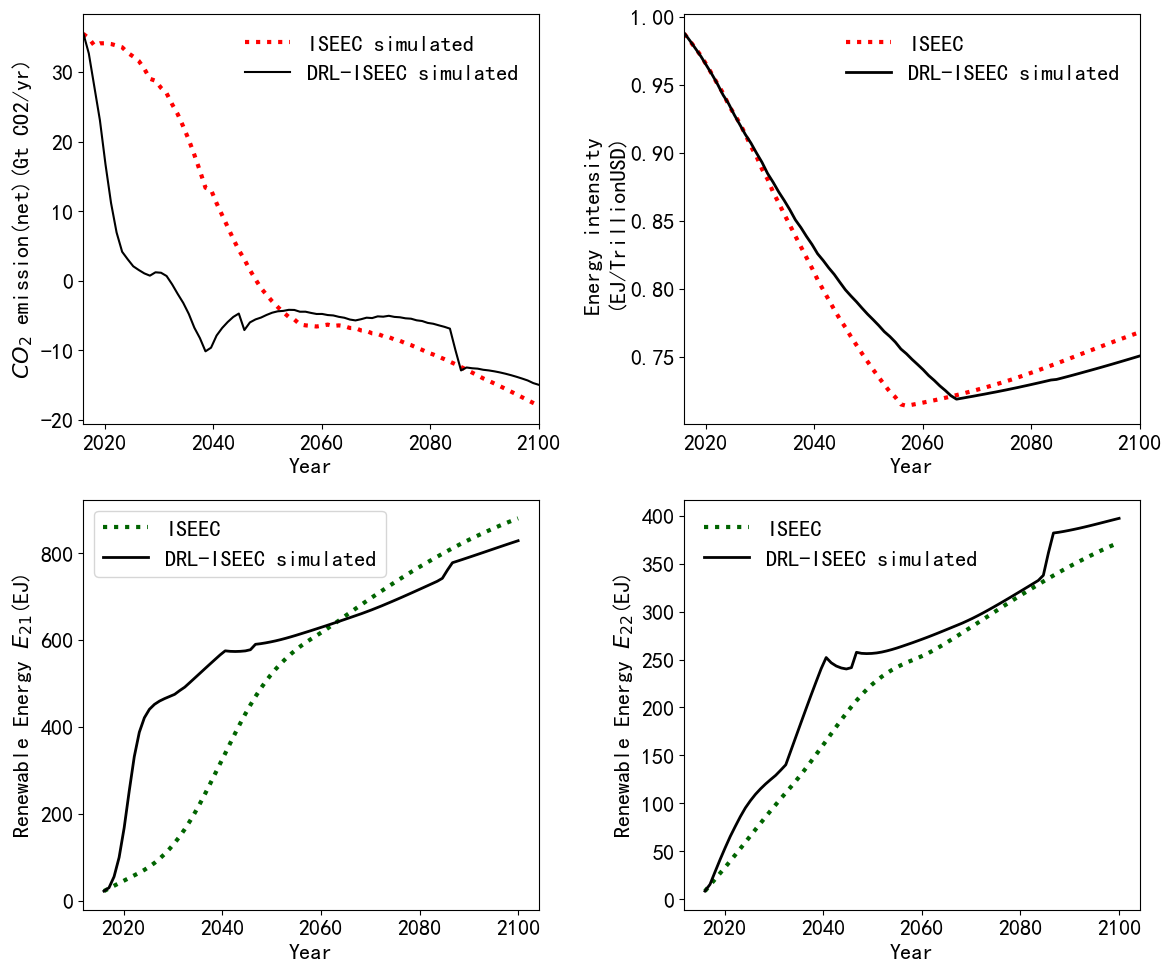

In [ ]:
# 绘制 state(share of renewable energy/co2 net emission co2 concentration/temperature)
# 读取 data 里面 compare_data 里面的相关数据进行比较绘制

import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

# 设置全局字体大小
plt.rcParams['font.size'] = 16

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

custom_reward_type = "weight_three_obj_over_same"
env = IEMEnv(reward_type=custom_reward_type)

# 读取第一维度数据:iseec-default
df_83_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_type1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第二维度数据 same weights 最新结果
df_83_type2 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")
df_251_type2 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

years = np.linspace(2016, 2100, 83)

# states_type1 = np.array(total_state_type1)
T_a_type1 = df_83_type1['T_a']
C_a_type1 = df_83_type1['C_a']

E21_type1 = df_83_type1['E21']
E22_type1 = df_83_type1['E22']
E23_type1 = df_83_type1['E23']
E24_type1 = df_83_type1['E24']
E12_type1 = df_83_type1['E12']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1 = df_251_type1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated_type1 = df_251_type1['energy_MYbaseline18502100_total_formulated']

E11_type1 = (
    energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:]
    - E21_type1
    - E22_type1
    - E23_type1
    - E24_type1
    - E12_type1
)

CO2emission_actualFF_type1 = df_251_type1['CO2emission_actualFF']
CO2emission_ACE1_type1 = df_251_type1['CO2emission_ACE1']
CO2emission_ACE2_type1 = df_251_type1['CO2emission_ACE2']
CO2emission_ACE3_type1 = df_251_type1['CO2emission_ACE3']
ratio_net_over_gross_type1 = df_251_type1['ratio_net_over_gross']
re_type1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1, 
        energy_MYbaseline18502100_total_formulated_type1
    )
][-83:]

# 区别
T_a_type2 = df_83_type2['T_a']
C_a_type2 = df_83_type2['C_a']

E21_type2 = df_83_type2['E21']
E22_type2 = df_83_type2['E22']
E23_type2 = df_83_type2['E23']
E24_type2 = df_83_type2['E24']
E12_type2 = df_83_type2['E12']

energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2 = df_251_type2['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated_type2 = df_251_type2['energy_MYbaseline18502100_total_formulated']

E11_type2 = (
    energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:]
    - E21_type2
    - E22_type2
    - E23_type2
    - E24_type2
    - E12_type2
)

CO2emission_actualFF_type2 = df_251_type2['CO2emission_actualFF']
CO2emission_ACE1_type2 = df_251_type2['CO2emission_ACE1']
CO2emission_ACE2_type2 = df_251_type2['CO2emission_ACE2']
CO2emission_ACE3_type2 = df_251_type2['CO2emission_ACE3']
ratio_net_over_gross_type2 = df_251_type2['ratio_net_over_gross']

re_type2 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2, 
        energy_MYbaseline18502100_total_formulated_type2
    )
][-83:]

################ 绘制 ##################
# 创建一个 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 统一的x轴
xlim = (2016, 2100)

# 子图1:
ax1 = axes[0, 0]
ax1.plot(years, [(x - b - c - d / e) * 44 / 12 for x, b, c, d, e in zip(CO2emission_actualFF_type1, CO2emission_ACE1_type1, CO2emission_ACE2_type1, CO2emission_ACE3_type1, ratio_net_over_gross_type1)][-83:], label='ISEEC simulated',linestyle='dotted', color='red', linewidth=3)
ax1.plot(years, [(x - b - c - d / e) * 44 / 12 for x, b, c, d, e in zip(CO2emission_actualFF_type2, CO2emission_ACE1_type2, CO2emission_ACE2_type2, CO2emission_ACE3_type2, ratio_net_over_gross_type2)][-83:], label='DRL-ISEEC simulated', color='black')

# 为IAMs曲线设置label，注意这里只在第一次绘制IAMs曲线时设置label，后续的IAMs曲线可以直接不设置label，
# 或者设置相同的label，因为它们通常代表同一组数据或模型变体
# 最好的做法是只在第一次 plot 时给 label，这样 legend 只有一个 "IAMs" 条目。
# ax1.plot(env.IAM_CO2emission.iloc[10-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[6-2,4:].astype('float')/1e3 , label = 'IAMs',linestyle='dotted', marker='',color = 'red') # 这一行已经有 label
# ax1.plot(env.IAM_CO2emission.iloc[11-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[7-2,4:].astype('float')/1e3, linestyle='dotted', marker='',color = 'red') # 无需重复设置 label，否则会创建多个相同的图例
# ax1.plot(env.IAM_CO2emission.iloc[12-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[8-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')
# ax1.plot(env.IAM_CO2emission.iloc[13-2,4:].astype('float')/1e3-env.IAM_CO2emission.iloc[9-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')

ax1.legend(frameon=False) # 加上这行即可显示图例
ax1.set_ylabel('$CO_2$ emission(net)(Gt CO2/yr)')
ax1.set_xlabel('Year')
ax1.set_xlim(xlim)


# 子图2: 
# ax2 = axes[0, 1]
# ax2.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], 
#         label='ISEEC simulated', color='blue')
# ax2.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], 
#         label='DRL-ISEEC simulated', color='black')
# ax2.plot(years, energy_MYbaseline18502100_total_formulated_type1[-83:], 
#         label='baseline', linestyle='dotted', color='red')
# ax2.set_ylabel('Total Energy (EJ)')
# ax2.set_xlabel('Year')
# ax2.set_xlim(xlim)
# # ax2.set_ylim(600, 1900)
# ax2.legend()
ax2 = axes[0, 1]
# ax2.plot(years, [-(b+c+d/e)*44/12 for b,c,d,e in zip(CO2emission_ACE1_type1,CO2emission_ACE2_type1,CO2emission_ACE3_type1, ratio_net_over_gross_type1)][-83:],  label = 'ISEEC simulated',color = 'red',linestyle = 'solid')
# ax2.plot(years, [-(b+c+d/e)*44/12 for b,c,d,e in zip(CO2emission_ACE1_type2,CO2emission_ACE2_type2,CO2emission_ACE3_type2, ratio_net_over_gross_type2)][-83:],  label = 'DRL-ISEEC simulated',color = 'black',linestyle = 'solid')
# ax2.plot( -env.IAM_CO2emission.iloc[6-2,4:].astype('float')/1e3 , label = 'IAMs',linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.plot( -env.IAM_CO2emission.iloc[7-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.plot( -env.IAM_CO2emission.iloc[8-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.plot( -env.IAM_CO2emission.iloc[9-2,4:].astype('float')/1e3 , linestyle='dotted', marker='',color = 'red')  # the 7th role is actual FF
# ax2.legend()
# ax2.set_ylabel('Atmospheric Carbon Extraction (Gt CO2/yr)')
# ax2.set_xlabel('Year')
# ax2.set_xlim(xlim)
ax2.plot(years, re_type1, label='ISEEC',  linestyle='dotted', color='red',linewidth=3)
ax2.plot(years, re_type2, label='DRL-ISEEC simulated', color='black',linewidth=2)
ax2.legend(frameon=False)
ax2.set_ylabel('Energy intensity \n(EJ/TrillionUSD)')
ax2.set_xlabel('Year')
ax2.set_xlim(xlim)


# 子图3: 
ax3 = axes[1, 0]
ax3.plot(years, E21_type1 , label='ISEEC', linestyle='dotted', marker='', color='darkgreen', linewidth=3) 
ax3.plot(years, E21_type2, label='DRL-ISEEC simulated',  color='black', linewidth=2) 
ax3.set_ylabel('Renewable Energy $E_{21}$(EJ)')
ax3.set_xlabel('Year')
ax3.legend()

# 子图4: 
ax4 = axes[1, 1]
ax4.plot(years, E22_type1, label='ISEEC', linestyle='dotted', marker='', color = 'darkgreen', linewidth=3)
ax4.plot(years, E22_type2, label='DRL-ISEEC simulated',  color = 'black', linewidth=2)
ax4.set_ylabel('Renewable Energy $E_{22}$(EJ)')
ax4.set_xlabel('Year')
ax4.legend(frameon=False)

# 调整布局以防止标签重叠
plt.tight_layout()
# 显示绘图
plt.show()



[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

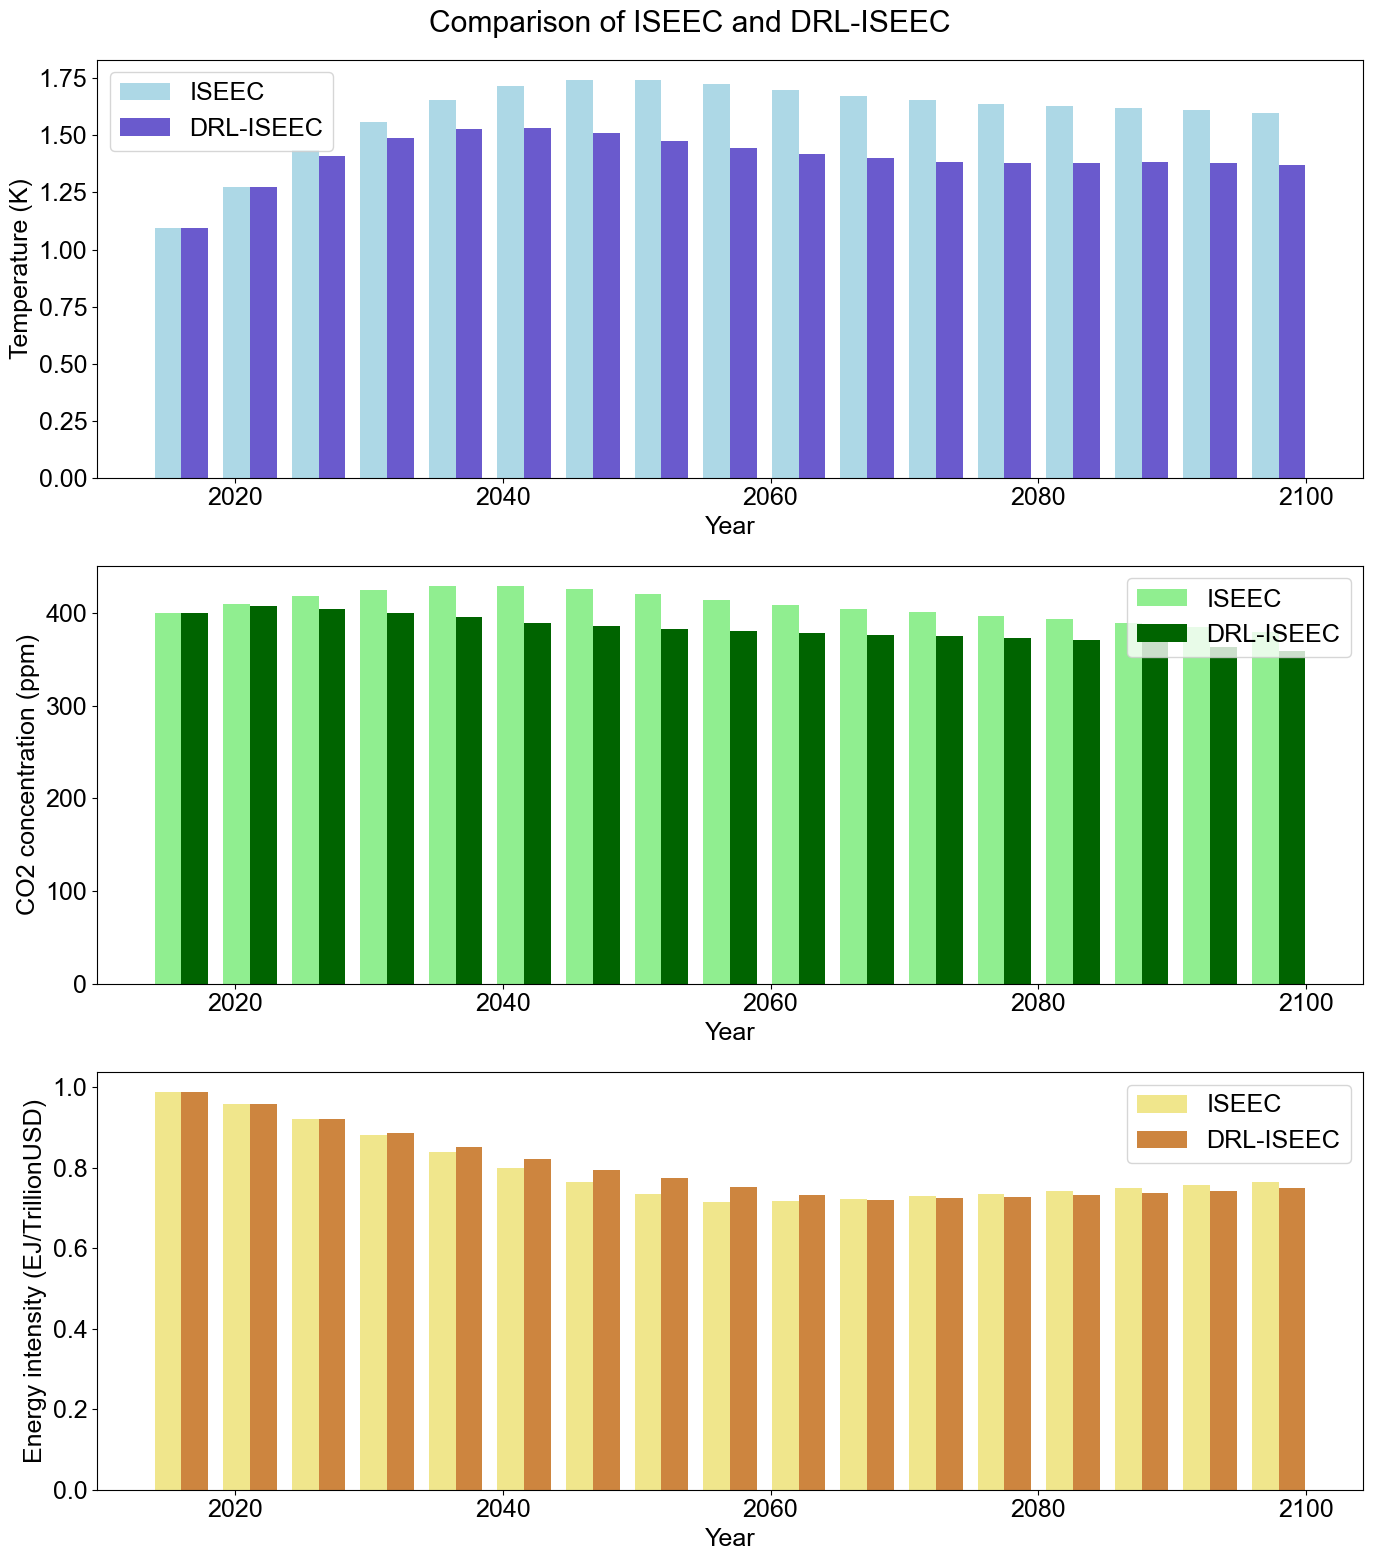

0.7681915107864435
0.7507157748779753


In [19]:
# 三个图分别绘制的版本

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

years = np.linspace(2016, 2100, 83)
custom_reward_type = "weight_three_obj_over_same"
env = IEMEnv(reward_type=custom_reward_type)

# 增加基准：iseec default 1.58 action=13 默认对比数据
df_83_baseline1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_baseline1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第三维度数据 multi obj
df_83_type3 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")
df_251_type3 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

# compare data 的相关变量(绘制时候再取相关的结果)
T_a_baseline1 = df_83_baseline1['T_a']
C_a_baseline1 = df_83_baseline1['C_a']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1 = df_251_baseline1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated = df_251_baseline1['energy_MYbaseline18502100_total_formulated']
E11_baseline1 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], df_83_baseline1['E12'], df_83_baseline1['E21'], df_83_baseline1['E22'], df_83_baseline1['E23'],df_83_baseline1['E24']
    )
]
re_baseline1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 3 的相关变量
action_total_type3 = df_83_type3['action_0']
T_a_type3 = df_83_type3['T_a']
C_a_type3 = df_83_type3['C_a']
CO2emission_actualFF_type3 = df_251_type3['CO2emission_actualFF']
CO2emission_ACE1_type3 = df_251_type3['CO2emission_ACE1']
CO2emission_ACE2_type3 = df_251_type3['CO2emission_ACE2']
CO2emission_ACE3_type3 = df_251_type3['CO2emission_ACE3']
ratio_net_over_gross_type3 = df_251_type3['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3 = df_251_type3['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
# E11
E12_type3 = df_83_type3['E12']
E21_type3 = df_83_type3['E21']
E22_type3 = df_83_type3['E22']
E23_type3 = df_83_type3['E23']
E24_type3 = df_83_type3['E24']
E11_type3 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], E12_type3, E21_type3, E22_type3, E23_type3, E24_type3
    )
]
re_type3 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# 绘制三个子图，分别绘制 Ta, Ca 和 re 的变化
fig, axs = plt.subplots(3, 1, figsize=(14, 16))
# 字体放大
plt.rcParams.update({'font.size': 18})

bar_width = 2

# 第一个子图：Ta
axs[0].bar(years[::5] - bar_width/2, T_a_baseline1[::5], width=bar_width, label='ISEEC', color='lightblue')
axs[0].bar(years[::5] + bar_width/2, T_a_type3[::5], width=bar_width, label='DRL-ISEEC', color='slateblue')
axs[0].set_ylabel('Temperature (K)')
axs[0].set_xlabel('Year')
axs[0].legend()

# 第二个子图：Ca
axs[1].bar(years[::5] - bar_width/2, C_a_baseline1[::5] * env.rho_a, width=bar_width, bottom=0, label='ISEEC', color='lightgreen')
axs[1].bar(years[::5] + bar_width/2, C_a_type3[::5] * env.rho_a, width=bar_width, bottom=0, label='DRL-ISEEC', color='darkgreen')
axs[1].set_ylabel('CO2 concentration (ppm)')
axs[1].set_xlabel('Year')
axs[1].legend()

# 第三个子图：re
axs[2].bar(years[::5] - bar_width/2, re_baseline1[::5], width=bar_width, label='ISEEC', color='khaki')
axs[2].bar(years[::5] + bar_width/2, re_type3[::5], width=bar_width, label='DRL-ISEEC', color='peru')
axs[2].set_ylabel('Energy intensity (EJ/TrillionUSD)')
axs[2].set_xlabel('Year')
axs[2].legend()

# 标题
plt.suptitle('Comparison of ISEEC and DRL-ISEEC')

plt.tight_layout()
plt.show()

print(re_baseline1[-1])
print(re_type3[-1])

In [ ]:
# 三元相图


C:\Users\14842\AppData\Local\Temp\ipykernel_176576\2296946606.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


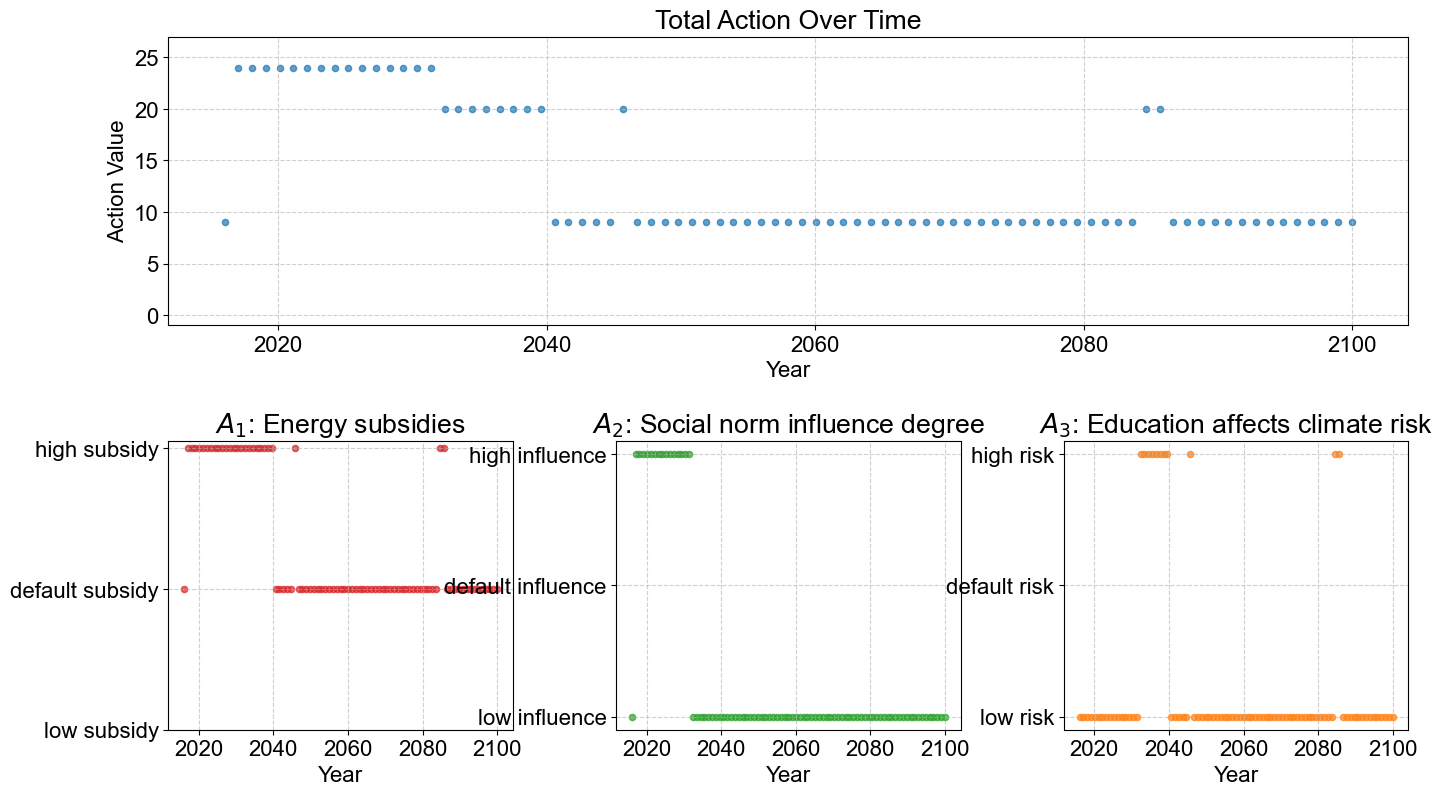

In [16]:
from cProfile import label
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # 导入 gridspec

# 设置全局字体大小和字体
plt.rcParams.update({'font.size': 16})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] # 常用的高质量期刊字体

# 读取数据
df_83_type1 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")

action_total_type1 = df_83_type1['action_0']
action_dim1_type1 = df_83_type1['action_dim1']
action_dim2_type1 = df_83_type1['action_dim2']
action_dim3_type1 = df_83_type1['action_dim3']

# 创建 figure
fig = plt.figure(figsize=(16, 9)) # 调整整体图的大小，更符合期刊排版
gs = gridspec.GridSpec(2, 3, wspace=0.3, hspace=0.4) # 调整子图间距

years = np.linspace(2016, 2100, 83)

# 第一行的大图
ax_total = fig.add_subplot(gs[:1, :])
ax_total.scatter(years, action_total_type1, color='#1f77b4', s=20, alpha=0.7)
ax_total.set_title('Total Action Over Time')
ax_total.set_ylabel('Action Value')
ax_total.set_xlabel('Year')
ax_total.set_ylim(-1, 27)
ax_total.grid(True, linestyle='--', alpha=0.6)

# 第二行的三个小图
ax_dim1 = fig.add_subplot(gs[-1, 0])
ax_dim1.scatter(years, action_dim1_type1, color='#d62728', s=20, alpha=0.7, label='Dim 1')
ax_dim1.set_title('$A_1$: Energy subsidies')
ax_dim1.set_xlabel('Year')
ax_dim1.grid(True, linestyle='--', alpha=0.6)
ax_dim1.set_yticks([0, 1, 2])
ax_dim1.set_yticklabels(['low subsidy', 'default subsidy', 'high subsidy'])

ax_dim2 = fig.add_subplot(gs[-1, 1])
ax_dim2.scatter(years, action_dim2_type1, color='#2ca02c', s=20, alpha=0.7, label='Dim 2')
ax_dim2.set_title('$A_2$: Social norm influence degree')
ax_dim2.set_xlabel('Year')
ax_dim2.grid(True, linestyle='--', alpha=0.6)
ax_dim2.set_yticks([0, 1, 2])
ax_dim2.set_yticklabels(['low influence', 'default influence', 'high influence'])

ax_dim3 = fig.add_subplot(gs[-1, 2])
ax_dim3.scatter(years, action_dim3_type1, color= '#ff7f0e', s=20, alpha=0.7, label='Dim 3')
ax_dim3.set_title('$A_3$: Education affects climate risk')
ax_dim3.set_xlabel('Year')
ax_dim3.grid(True, linestyle='--', alpha=0.6)
ax_dim3.set_yticks([0, 1, 2])
ax_dim3.set_yticklabels(['low risk', 'default risk', 'high risk'])

plt.tight_layout()
plt.show()



C:\Users\14842\AppData\Local\Temp\ipykernel_176576\2296946606.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


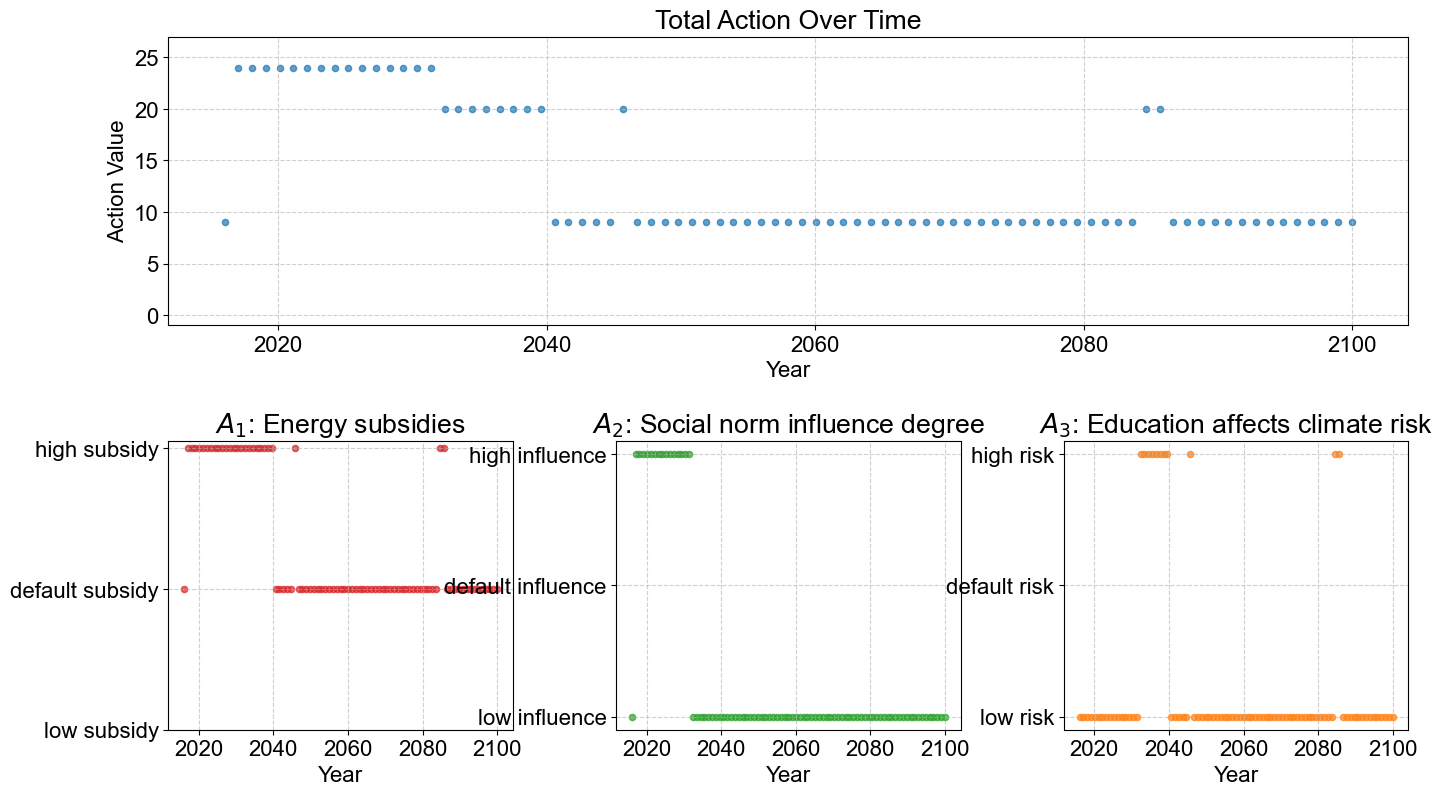

C:\Users\14842\AppData\Local\Temp\ipykernel_176576\3296655162.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


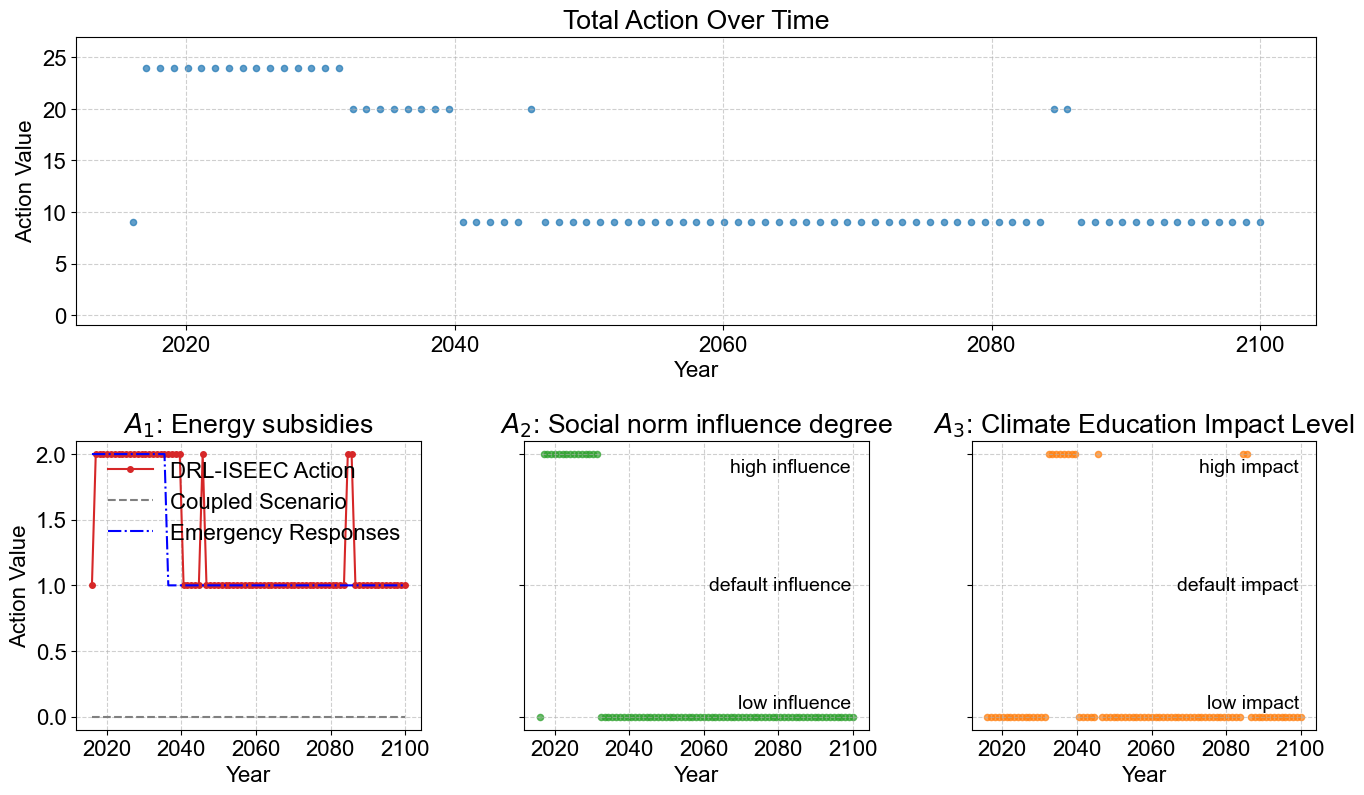

In [51]:
from cProfile import label
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # 导入 gridspec
from matplotlib.offsetbox import AnchoredText # 导入 AnchoredText

# 设置全局字体大小和字体
plt.rcParams.update({'font.size': 16})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] # 常用的高质量期刊字体

# 读取数据
df_83_type1 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")

action_total_type1 = df_83_type1['action_0']
action_dim1_type1 = df_83_type1['action_dim1']
action_dim2_type1 = df_83_type1['action_dim2']
action_dim3_type1 = df_83_type1['action_dim3']

# 创建 figure
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, wspace=0.3, hspace=0.4)

# 第一行的大图
ax_total = fig.add_subplot(gs[:1, :])
ax_total.scatter(years, action_total_type1, color='#1f77b4', s=20, alpha=0.7)
ax_total.set_title('Total Action Over Time')
ax_total.set_ylabel('Action Value')
ax_total.set_xlabel('Year')
ax_total.set_ylim(-1, 27)
ax_total.grid(True, linestyle='--', alpha=0.6)

# 第二行的三个小图
# 假设你已经有了 DRL-ISEEC 的 action_dim1_type1 数据
# 这里我们创建两个模拟的基准情景数据
# Coupled 情景：action_dim1 始终为 0
action_dim1_coupled = [0] * len(years) 
# All Emergency Responses 情景：假设早期为 2，后期为 1
action_dim1_emergency = [2] * 20 + [1] * (len(years) - 20) 

ax_dim1 = fig.add_subplot(gs[-1, 0])
# 绘制 DRL 的动态决策
ax_dim1.plot(years, action_dim1_type1, label='DRL-ISEEC Action', color='#d62728', linestyle='-', marker='o', markersize=4)
# 绘制 Coupled 情景的静态决策
ax_dim1.plot(years, action_dim1_coupled, label='Coupled Scenario', color='gray', linestyle='--')
# 绘制 All Emergency Responses 情景的预设决策
ax_dim1.plot(years, action_dim1_emergency, label='Emergency Responses', color='blue', linestyle='-.')

ax_dim1.set_title('$A_1$: Energy subsidies')
ax_dim1.set_xlabel('Year')
ax_dim1.set_ylabel('Action Value')
ax_dim1.grid(True, linestyle='--', alpha=0.6)
ax_dim1.legend(frameon=False)


ax_dim2 = fig.add_subplot(gs[-1, 1])
ax_dim2.scatter(years, action_dim2_type1, color='#2ca02c', s=20, alpha=0.7)
ax_dim2.set_title('$A_2$: Social norm influence degree')
ax_dim2.set_xlabel('Year')
ax_dim2.grid(True, linestyle='--', alpha=0.6)
ax_dim2.set_yticks([0, 1, 2])
ax_dim2.set_yticklabels(['', '', ''])
at4 = AnchoredText("low influence", loc='lower right', frameon=False, prop=dict(size=14, color='black'))
at5 = AnchoredText("default influence", loc='center right', frameon=False, prop=dict(size=14, color='black'))
at6 = AnchoredText("high influence", loc='upper right', frameon=False, prop=dict(size=14, color='black'))
ax_dim2.add_artist(at4)
ax_dim2.add_artist(at5)
ax_dim2.add_artist(at6)

ax_dim3 = fig.add_subplot(gs[-1, 2])
ax_dim3.scatter(years, action_dim3_type1, color='#ff7f0e', s=20, alpha=0.7)
ax_dim3.set_title('$A_3$: Climate Education Impact Level')
ax_dim3.set_xlabel('Year')
ax_dim3.grid(True, linestyle='--', alpha=0.6)
ax_dim3.set_yticks([0, 1, 2])
ax_dim3.set_yticklabels(['', '', ''])
at7 = AnchoredText("low impact", loc='lower right', frameon=False, prop=dict(size=14, color='black'))
at8 = AnchoredText("default impact", loc='center right', frameon=False, prop=dict(size=14, color='black'))
at9 = AnchoredText("high impact", loc='upper right', frameon=False, prop=dict(size=14, color='black'))
ax_dim3.add_artist(at7)
ax_dim3.add_artist(at8)
ax_dim3.add_artist(at9)

plt.tight_layout()
plt.show()



C:\Users\14842\AppData\Local\Temp\ipykernel_176576\4187099533.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


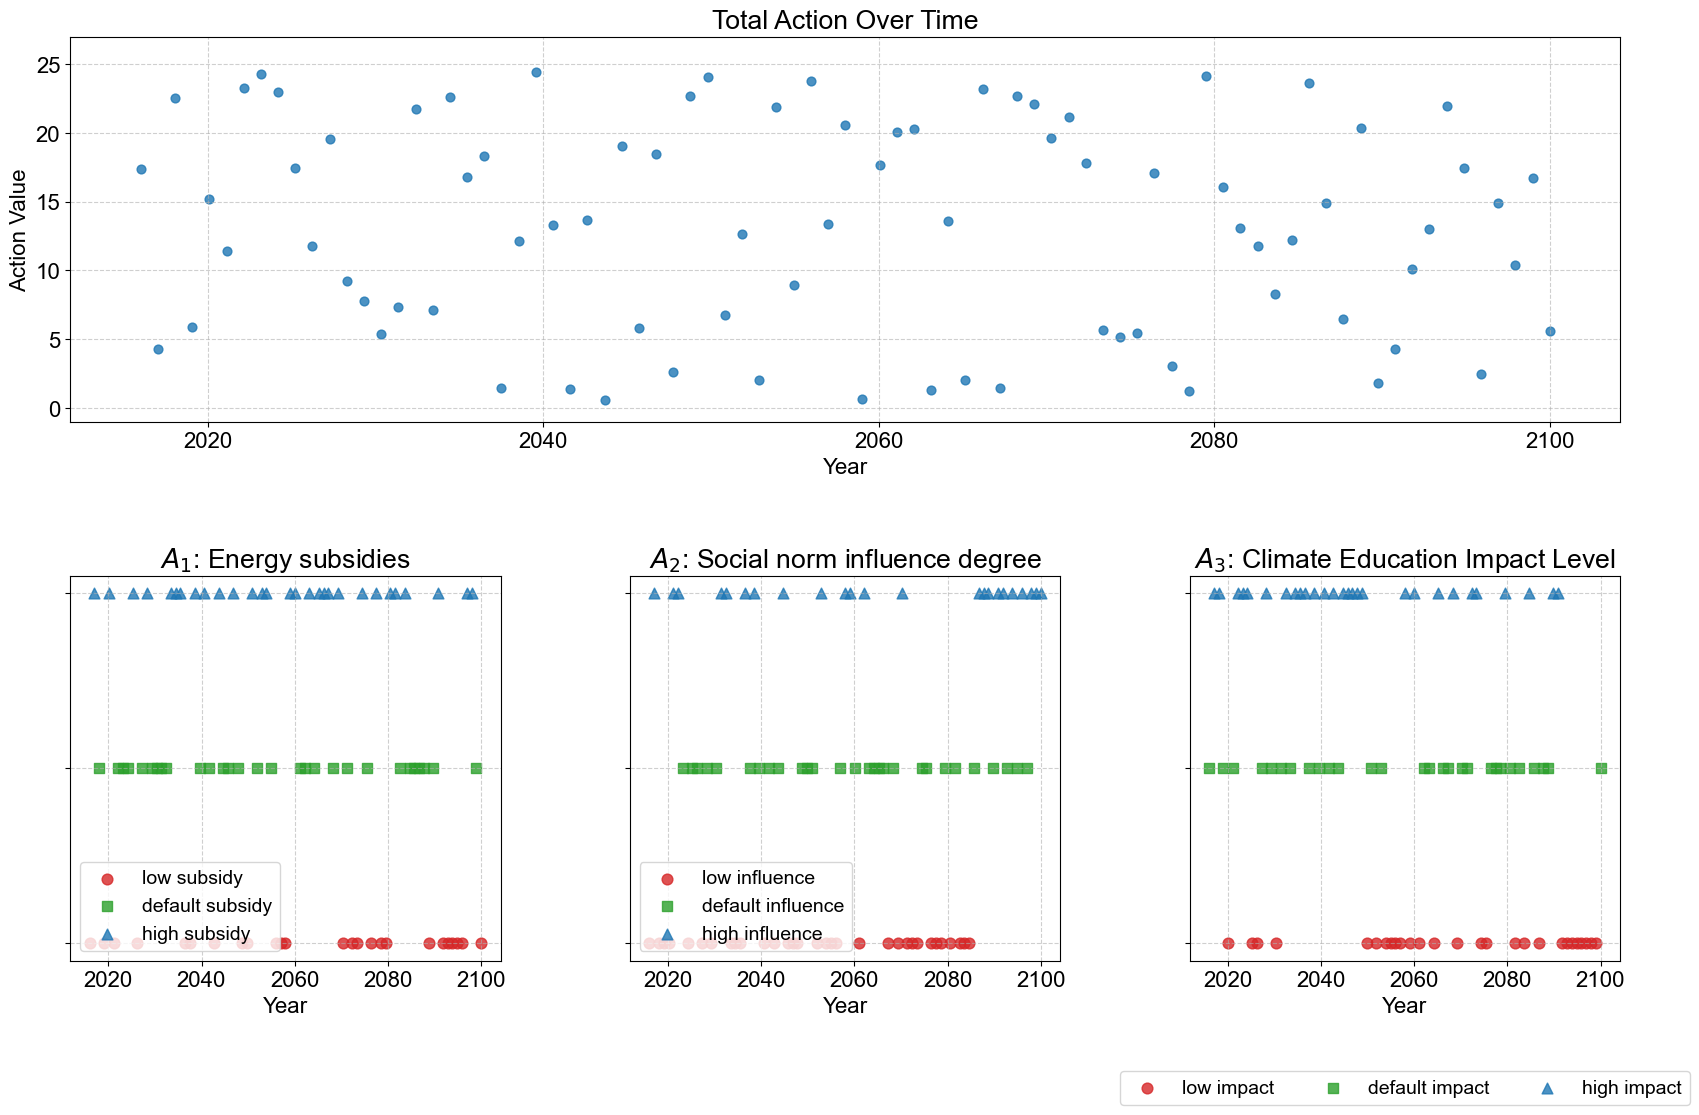

In [ ]:
from cProfile import label
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # 导入 gridspec

# 设置全局字体大小和字体
plt.rcParams.update({'font.size': 16})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] # 常用的高质量期刊字体

# 读取数据
# 假设你已经有了数据，这里使用示例数据
# df_83_type1 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")
years = np.linspace(2016, 2100, 83)
# 假设从文件中读取的数据
action_total_type1 = np.random.rand(len(years)) * 26
action_dim1_type1 = np.random.choice([0, 1, 2], size=len(years))
action_dim2_type1 = np.random.choice([0, 1, 2], size=len(years))
action_dim3_type1 = np.random.choice([0, 1, 2], size=len(years))


# 创建 figure，调整整体图的大小，使其更宽更高
fig = plt.figure(figsize=(20, 12)) # 增大图表尺寸
gs = gridspec.GridSpec(2, 3, wspace=0.3, hspace=0.4) # 调整子图间距

# 第一行的大图
ax_total = fig.add_subplot(gs[:1, :]) # gs[:1, :] 表示第0行
ax_total.scatter(years, action_total_type1, color='#1f77b4', s=40, alpha=0.8) # 调整点的大小和透明度
ax_total.set_title('Total Action Over Time') # 调整标题字体大小
ax_total.set_ylabel('Action Value') # 更具体的标签
ax_total.set_xlabel('Year')
ax_total.set_ylim(-1, 27)
ax_total.grid(True, linestyle='--', alpha=0.6) # 更柔和的网格线

# 第二行的三个小图：分别占据第二行的第 0, 1, 2 列
# A1: Energy subsidies
ax_dim1 = fig.add_subplot(gs[-1, 0]) # gs[-1, 0] 表示最后一行，第0列
# 将数据根据动作值进行分类
data_dim1_low = years[action_dim1_type1 == 0]
data_dim1_default = years[action_dim1_type1 == 1]
data_dim1_high = years[action_dim1_type1 == 2]

# 增大 s 参数，使符号更明显
ax_dim1.scatter(data_dim1_low, [0] * len(data_dim1_low), color='#d62728', s=60, marker='o', alpha=0.8, label='low subsidy')
ax_dim1.scatter(data_dim1_default, [1] * len(data_dim1_default), color='#2ca02c', s=60, marker='s', alpha=0.8, label='default subsidy')
ax_dim1.scatter(data_dim1_high, [2] * len(data_dim1_high), color='#1f77b4', s=60, marker='^', alpha=0.8, label='high subsidy')

ax_dim1.set_title('$A_1$: Energy subsidies')
ax_dim1.set_xlabel('Year')
ax_dim1.grid(True, linestyle='--', alpha=0.6)
ax_dim1.set_yticks([0, 1, 2])
ax_dim1.set_yticklabels(['', '', ''])  # 隐藏Y轴刻度标签
ax_dim1.legend(loc='lower left', fontsize=14) # 调整图例位置和字体大小

# A2: Social norm influence degree
ax_dim2 = fig.add_subplot(gs[-1, 1]) # gs[-1, 1]
data_dim2_low = years[action_dim2_type1 == 0]
data_dim2_default = years[action_dim2_type1 == 1]
data_dim2_high = years[action_dim2_type1 == 2]

ax_dim2.scatter(data_dim2_low, [0] * len(data_dim2_low), color='#d62728', s=60, marker='o', alpha=0.8, label='low influence')
ax_dim2.scatter(data_dim2_default, [1] * len(data_dim2_default), color='#2ca02c', s=60, marker='s', alpha=0.8, label='default influence')
ax_dim2.scatter(data_dim2_high, [2] * len(data_dim2_high), color='#1f77b4', s=60, marker='^', alpha=0.8, label='high influence')

ax_dim2.set_title('$A_2$: Social norm influence degree')
ax_dim2.set_xlabel('Year')
ax_dim2.grid(True, linestyle='--', alpha=0.6)
ax_dim2.set_yticks([0, 1, 2])
ax_dim2.set_yticklabels(['', '', ''])
ax_dim2.legend(loc='lower left', fontsize=14)

# A3: Climate Education Impact Level
ax_dim3 = fig.add_subplot(gs[-1, 2]) # gs[-1, 2]
data_dim3_low = years[action_dim3_type1 == 0]
data_dim3_default = years[action_dim3_type1 == 1]
data_dim3_high = years[action_dim3_type1 == 2]

ax_dim3.scatter(data_dim3_low, [0] * len(data_dim3_low), color='#d62728', s=60, marker='o', alpha=0.8, label='low impact')
ax_dim3.scatter(data_dim3_default, [1] * len(data_dim3_default), color='#2ca02c', s=60, marker='s', alpha=0.8, label='default impact')
ax_dim3.scatter(data_dim3_high, [2] * len(data_dim3_high), color='#1f77b4', s=60, marker='^', alpha=0.8, label='high impact')

ax_dim3.set_title('$A_3$: Climate Education Impact Level')
ax_dim3.set_xlabel('Year')
ax_dim3.grid(True, linestyle='--', alpha=0.6)
ax_dim3.set_yticks([0, 1, 2])
ax_dim3.set_yticklabels(['', '', ''])
ax_dim3.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=3, fontsize=14)

plt.tight_layout()
plt.show()

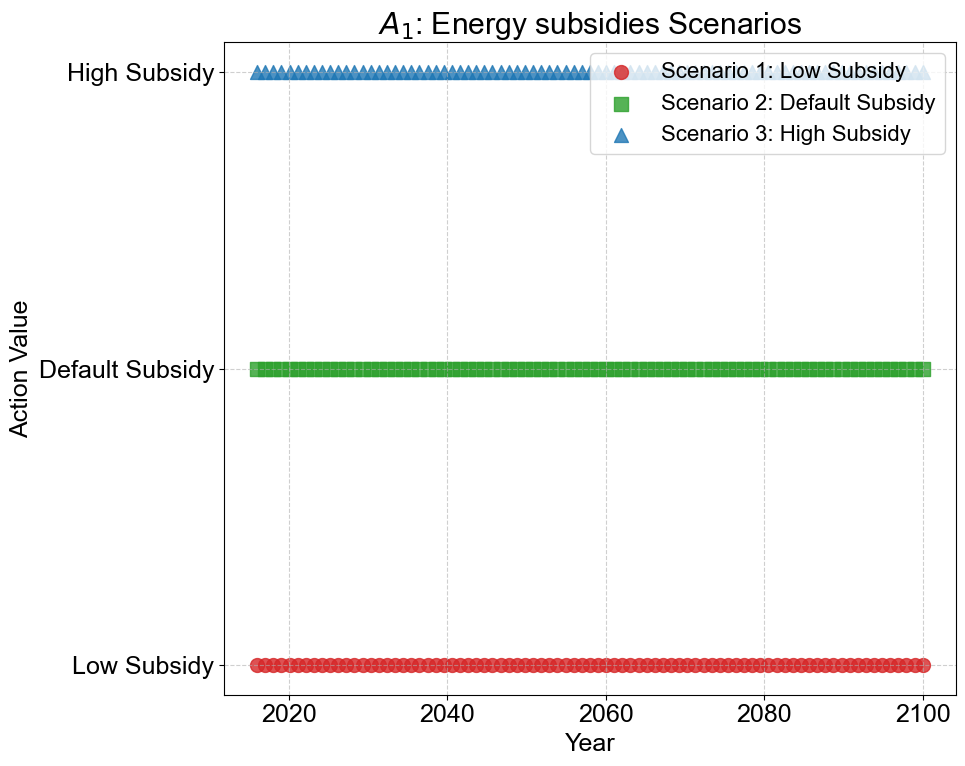

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 设置全局字体大小和字体
plt.rcParams.update({'font.size': 18})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 定义时间序列
years = np.linspace(2016, 2100, 83)

# 假设三种情景的动作值是固定的
# 情景 1: low subsidy (值为 0)
action_scenario1_val = 0
action_scenario1 = np.full(len(years), action_scenario1_val)

# 情景 2: default subsidy (值为 1)
action_scenario2_val = 1
action_scenario2 = np.full(len(years), action_scenario2_val)

# 情景 3: high subsidy (值为 2)
action_scenario3_val = 2
action_scenario3 = np.full(len(years), action_scenario3_val)

# 创建 figure 和 axes，调整图表大小以突出显示
fig, ax = plt.subplots(figsize=(10, 8))

# 绘制三种情景，使用不同的颜色、符号和标签
ax.scatter(years, action_scenario1, color='#d62728', s=100, marker='o', alpha=0.8, label='Scenario 1: Low Subsidy')
ax.scatter(years, action_scenario2, color='#2ca02c', s=100, marker='s', alpha=0.8, label='Scenario 2: Default Subsidy')
ax.scatter(years, action_scenario3, color='#1f77b4', s=100, marker='^', alpha=0.8, label='Scenario 3: High Subsidy')

# 设置图表标题和标签
ax.set_title('$A_1$: Energy subsidies Scenarios')
ax.set_ylabel('Action Value')
ax.set_xlabel('Year')

# 设置 y 轴刻度，使其与情景值对应
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Low Subsidy', 'Default Subsidy', 'High Subsidy'])

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.6)

# 添加图例
ax.legend(loc='upper right', fontsize=16)

# 调整布局并显示图表
plt.tight_layout()
plt.show()


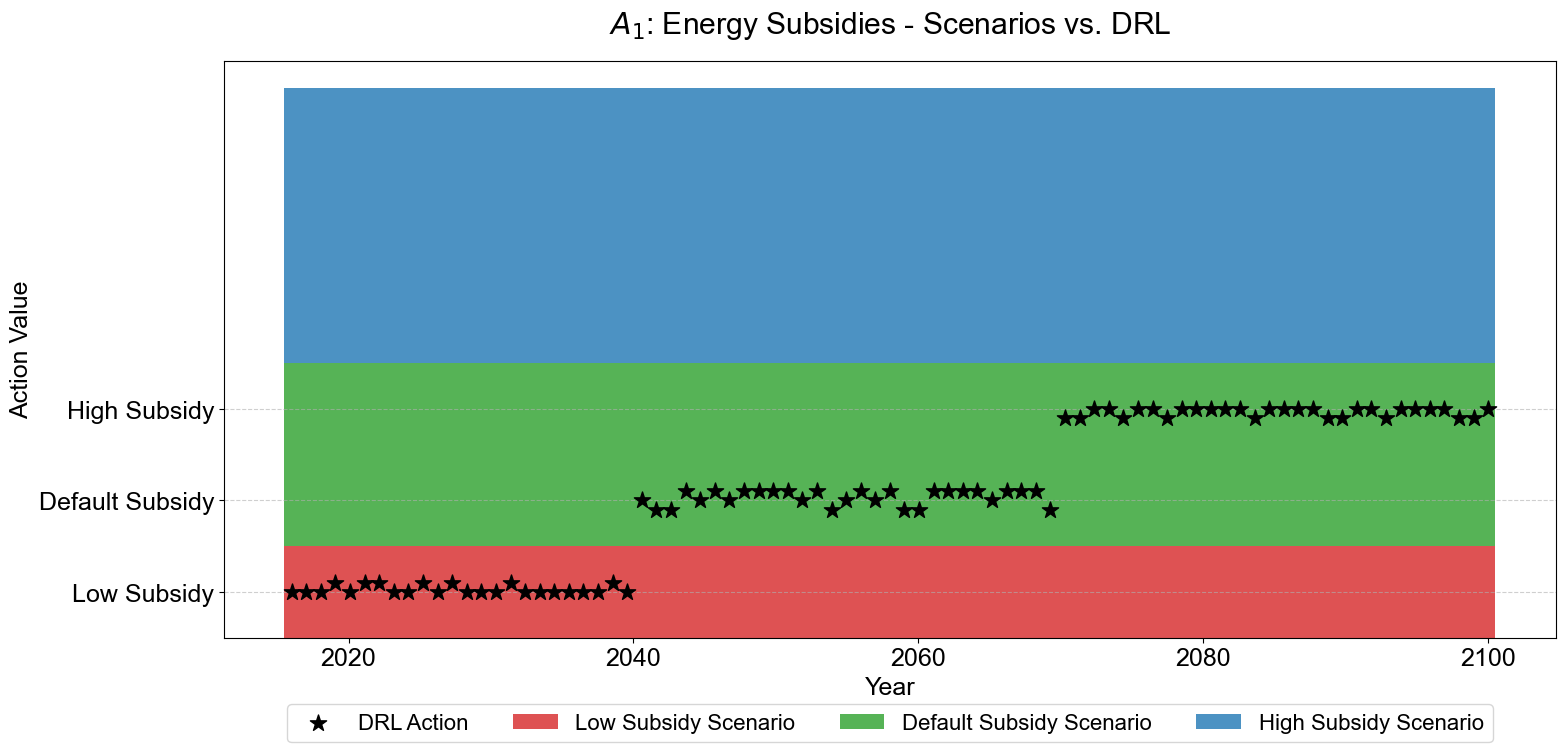

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 设置全局字体大小和字体
plt.rcParams.update({'font.size': 18})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 定义时间序列
years = np.linspace(2016, 2100, 83)
time_step = years[1] - years[0] # 计算时间步长

# --- 常规情景模拟数据 (A1: Energy subsidies) ---
action_scenario1_val = 0 # low subsidy
action_scenario2_val = 1 # default subsidy
action_scenario3_val = 2 # high subsidy

action_scenario1 = np.full(len(years), action_scenario1_val)
action_scenario2 = np.full(len(years), action_scenario2_val)
action_scenario3 = np.full(len(years), action_scenario3_val)

# --- DRL 动作模拟数据 (A1: Energy subsidies) ---
drl_action_a1 = np.zeros(len(years))
drl_action_a1[years <= 2040] = 0
drl_action_a1[(years > 2040) & (years <= 2070)] = 1
drl_action_a1[years > 2070] = 2
drl_action_a1 = drl_action_a1 + np.random.choice([-0.1, 0, 0.1], size=len(years))
drl_action_a1 = np.clip(drl_action_a1, 0, 2)


# 创建 figure 和 axes
fig, ax = plt.subplots(figsize=(16, 9))

# --- 绘制常规情景 (堆叠条形图) ---
ax.bar(years, action_scenario1 + 1, color='#d62728', width=time_step, alpha=0.8, label='Low Subsidy Scenario')
ax.bar(years, action_scenario2 + 1, bottom=action_scenario1 + 1, color='#2ca02c', width=time_step, alpha=0.8, label='Default Subsidy Scenario')
ax.bar(years, action_scenario3 + 1, bottom=action_scenario1 + 1 + action_scenario2 + 1, color='#1f77b4', width=time_step, alpha=0.8, label='High Subsidy Scenario')


# --- 绘制 DRL 动作 (散点图) ---
ax.scatter(years, drl_action_a1 + 0.5, color='black', s=150, marker='*', alpha=1.0, zorder=5, label='DRL Action') # 使用 +0.5 偏移，使其位于条形图中心


# 设置图表标题和标签
ax.set_title('$A_1$: Energy Subsidies - Scenarios vs. DRL', pad=20)
ax.set_ylabel('Action Value')
ax.set_xlabel('Year')

# 设置 Y 轴刻度
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['Low Subsidy', 'Default Subsidy', 'High Subsidy'])
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 调整 X 轴刻度
ax.set_xticks(np.arange(2020, 2101, 20))

# 调整图例
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=16)

# 调整布局以适应图表
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# different reward 绘制变化

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

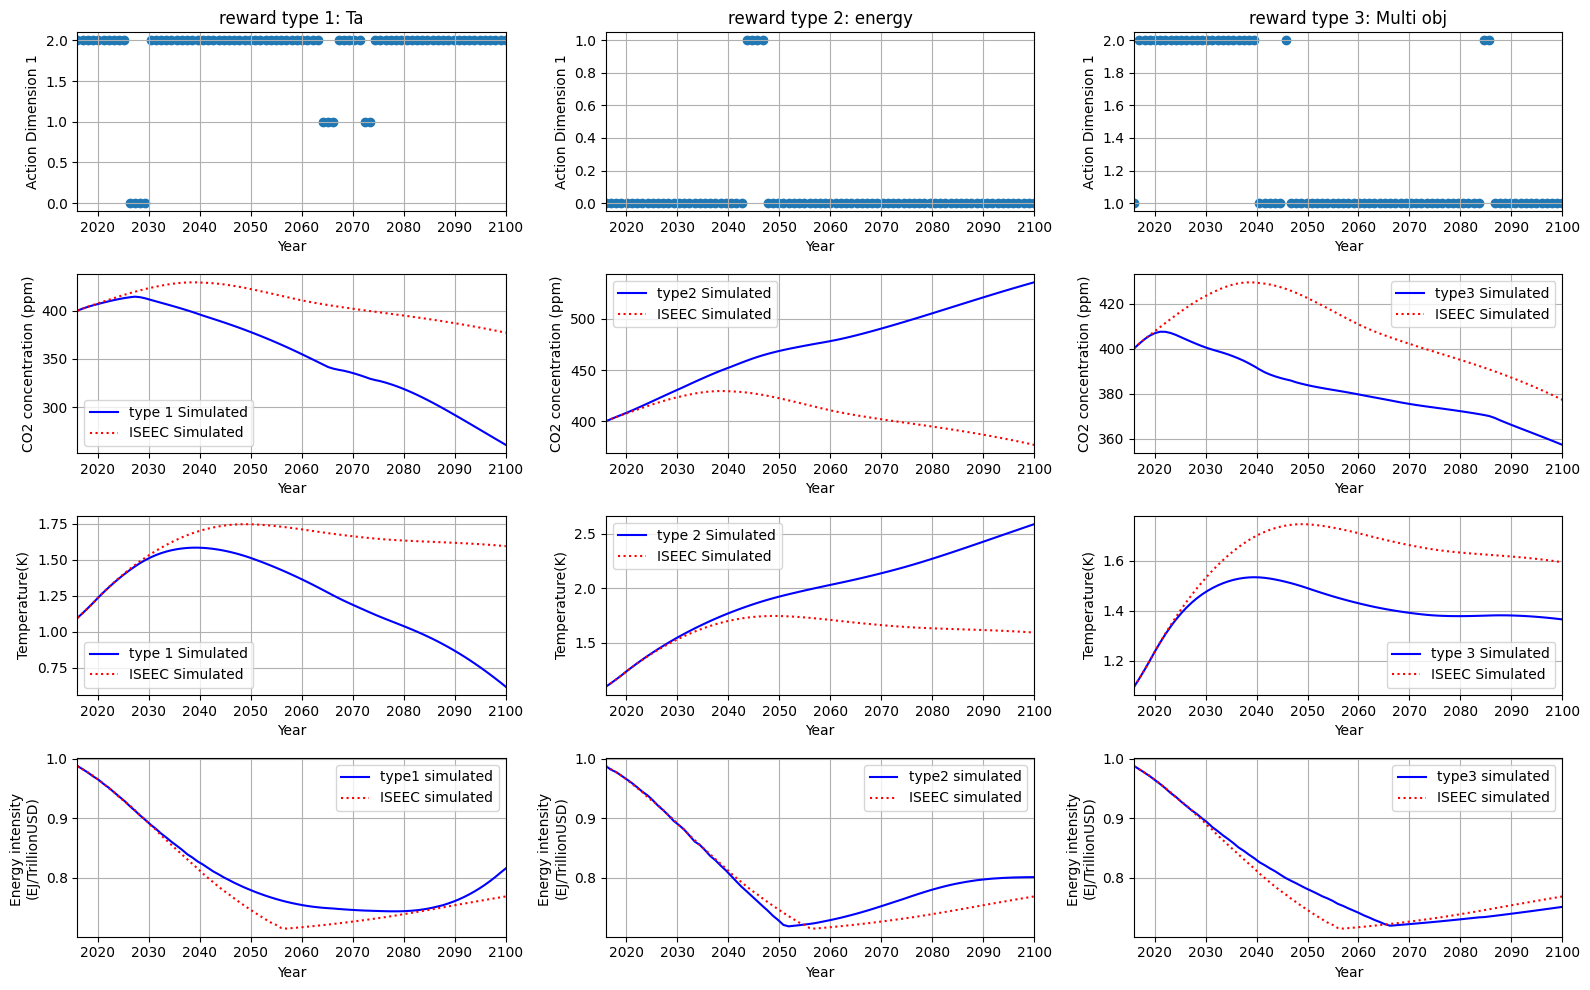

final result
累计结果打印
-------Ta---------
Ta_baseline1_cumulative: 133.22059348309156
Ta_type1_cumulative: 103.37658947987605
Ta_type2_cumulative: 162.9349467594065
Ta_type3_cumulative: 117.15917820965129
-------Ca(ppm) C_a_baseline1 * env.rho_a ---------
Ca_baseline1_cumulative: 33847.66748190788
Ca_type1_cumulative: 29471.922333378086
Ca_type2_cumulative: 39318.76942374011
Ca_type3_cumulative: 31760.81803322746
-------re---------
re_baseline1_cumulative: 65.61106826307731
re_type1_cumulative: 66.97774874039513
re_type2_cumulative: 66.80894044982296
re_type3_cumulative: 66.04834644951669
-------total_energy---------
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1_cumulative: 116395.83258005054
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1_cumulative: 118396.23232215644
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2_cumulative: 118524.66352421785
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3_cumulative: 116762.1336324201


In [3]:

# 绘制不同 Reward 下的状态变化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions_re import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

years = np.linspace(2016, 2100, 83)
custom_reward_type = "distance_with_normalized_over"
env = IEMEnv(reward_type=custom_reward_type)

# 增加基准：iseec default 1.58 action=13 默认对比数据
df_83_baseline1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\episode_0_results_20250724_202537.xlsx")
df_251_baseline1 = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")

# 读取第一维度数据: Ta-test
df_83_type1 = pd.read_excel(rf"data\compare_data\250728 v2 Ta\episode_0_results_20250729_130705.xlsx")
df_251_type1 = pd.read_excel(rf"data\compare_data\250728 v2 Ta\iseec_ssp5_MIT_data_diy_weight_three_obj_over_DQN_Ta.xlsx")

# 读取第二维度: energy
df_83_type2 = pd.read_excel(rf"data\compare_data\250729 v2_re_energy_cost\episode_0_results_20250731_212612.xlsx")
df_251_type2 = pd.read_excel(rf"data\compare_data\250729 v2_re_energy_cost\iseec_ssp5_MIT_data_diy_weight_three_obj_over_DQN_re_energy_intensity_cost.xlsx")

# 读取第三维度数据 multi obj
df_83_type3 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")
df_251_type3 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

# compare data 的相关变量
T_a_baseline1 = df_83_baseline1['T_a']
C_a_baseline1 = df_83_baseline1['C_a']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1 = df_251_baseline1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
energy_MYbaseline18502100_total_formulated = df_251_baseline1['energy_MYbaseline18502100_total_formulated']
E11_baseline1 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], df_83_baseline1['E12'], df_83_baseline1['E21'], df_83_baseline1['E22'], df_83_baseline1['E23'],df_83_baseline1['E24']
    )
]
re_baseline1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 1 的相关变量
action_total_type1 = df_83_type1['action_0']
action_dim1_type1 = df_83_type1['action_dim1']
T_a_type1 = df_83_type1['T_a']
C_a_type1 = df_83_type1['C_a']
CO2emission_actualFF_type1 = df_251_type1['CO2emission_actualFF']
CO2emission_ACE1_type1 = df_251_type1['CO2emission_ACE1']
CO2emission_ACE2_type1 = df_251_type1['CO2emission_ACE2']
CO2emission_ACE3_type1 = df_251_type1['CO2emission_ACE3']
ratio_net_over_gross_type1 = df_251_type1['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1 = df_251_type1['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
# 增加对 E11 和 re 变量的绘制
# E11 的读取
E12_type1 = df_83_type1['E12']
E21_type1 = df_83_type1['E21']
E22_type1 = df_83_type1['E22']
E23_type1 = df_83_type1['E23']
E24_type1 = df_83_type1['E24']
E11_type1 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], E12_type1, E21_type1, E22_type1, E23_type1, E24_type1
    )
]
# re 的读取
# 计算 re_type1 的值，并取最后 83 个元素
re_type1 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 2 的相关变量
action_total_type2 = df_83_type2['action_0']
action_dim1_type2 = df_83_type2['action_dim1']
T_a_type2 = df_83_type2['T_a']
C_a_type2 = df_83_type2['C_a']
CO2emission_actualFF_type2 = df_251_type2['CO2emission_actualFF']
CO2emission_ACE1_type2 = df_251_type2['CO2emission_ACE1']
CO2emission_ACE2_type2 = df_251_type2['CO2emission_ACE2']
CO2emission_ACE3_type2 = df_251_type2['CO2emission_ACE3']
ratio_net_over_gross_type2 = df_251_type2['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2 = df_251_type2['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
energy_MYadjusted18502100_total_type2 = df_251_type2['energy_MYadjusted18502100_total']
# E11
E12_type2 = df_83_type2['E12']
E21_type2 = df_83_type2['E21']
E22_type2 = df_83_type2['E22']
E23_type2 = df_83_type2['E23']
E24_type2 = df_83_type2['E24']
E11_type2 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], E12_type2, E21_type2, E22_type2, E23_type2, E24_type2
    )
]
re_type2 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# type 3 的相关变量
action_total_type3 = df_83_type3['action_0']
action_dim1_type3 = df_83_type3['action_dim1']
T_a_type3 = df_83_type3['T_a']
C_a_type3 = df_83_type3['C_a']
CO2emission_actualFF_type3 = df_251_type3['CO2emission_actualFF']
CO2emission_ACE1_type3 = df_251_type3['CO2emission_ACE1']
CO2emission_ACE2_type3 = df_251_type3['CO2emission_ACE2']
CO2emission_ACE3_type3 = df_251_type3['CO2emission_ACE3']
ratio_net_over_gross_type3 = df_251_type3['ratio_net_over_gross']
energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3 = df_251_type3['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']   
# E11
E12_type3 = df_83_type3['E12']
E21_type3 = df_83_type3['E21']
E22_type3 = df_83_type3['E22']
E23_type3 = df_83_type3['E23']
E24_type3 = df_83_type3['E24']
E11_type3 = [
    energy - e12 - e21 - e22 - e23 - e24
    for energy, e12, e21, e22, e23, e24 in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], E12_type3, E21_type3, E22_type3, E23_type3, E24_type3
    )
]
re_type3 = [
    e_adjusted / e_all
    for e_adjusted, e_all in zip(
        energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3, 
        energy_MYbaseline18502100_total_formulated
    )
][-83:]

# 开始绘制
fig, axes = plt.subplots(4, 3, figsize=(16, 10))

xlim = (2016, 2100)

# ax1 = axes[0, 0]
# # 利用散点图绘制 action
# ax1.scatter(years, action_total_type1)
# ax1.set_xlabel('Year')
# ax1.set_ylabel('action')
# ax1.set_title('reward type 1: Ta')
# ax1.set_xlim(xlim)
# ax1.grid(True)

# # 利用散点图绘制 action
# ax2 = axes[0, 1]
# ax2.scatter(years, action_total_type2)
# ax2.set_xlabel('Year')
# ax2.set_ylabel('action')
# ax2.set_title('reward type 2: energy')
# ax2.set_xlim(xlim)
# ax2.grid(True)

# # 利用散点图绘制 action
# ax3 = axes[0, 2]
# ax3.scatter(years, action_total_type3)
# ax3.set_xlabel('Year')
# ax3.set_ylabel('action')
# ax3.set_title('reward type 3: Multi obj')
# ax3.set_xlim(xlim)
# ax3.grid(True)

ax1 = axes[0, 0]
# 利用散点图绘制 action
ax1.scatter(years, action_dim1_type1)
ax1.set_xlabel('Year')
ax1.set_ylabel('Action Dimension 1')
ax1.set_title('reward type 1: Ta')
ax1.set_xlim(xlim)
ax1.grid(True)

# 利用散点图绘制 action
ax2 = axes[0, 1]
ax2.scatter(years, action_dim1_type2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Action Dimension 1')
ax2.set_title('reward type 2: energy')
ax2.set_xlim(xlim)
ax2.grid(True)

# 利用散点图绘制 action
ax3 = axes[0, 2]
ax3.scatter(years, action_dim1_type3)
ax3.set_xlabel('Year')
ax3.set_ylabel('Action Dimension 1')
ax3.set_title('reward type 3: Multi obj')
ax3.set_xlim(xlim)
ax3.grid(True)

# # 增加对分维度的绘制
# axe4 = axes[1, 0]
# ax4 = axes[0, 0]
# # 利用散点图绘制 action
# ax4.scatter(years, action_total_type1)
# ax4.set_xlabel('Year')
# ax4.set_ylabel('action')
# ax4.set_title('reward type 1: Ta')
# ax4.set_xlim(xlim)
# ax4.grid(True)

ax4 = axes[1, 0]
ax4.plot(years, C_a_type1 * env.rho_a, label='type 1 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax4.plot(years, C_a_baseline1 * env.rho_a, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
# ax4.plot(env.IAM_CO2concentration.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_CO2concentration.iloc[3-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_CO2concentration.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
# ax4.plot(env.IAM_CO2concentration.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
ax4.set_ylabel("CO2 concentration (ppm)")
ax4.set_xlabel('Year')
ax4.set_xlim(xlim)
ax4.legend()
ax4.grid(True)

ax5 = axes[1, 1]
ax5.plot(years, C_a_type2 * env.rho_a, label='type2 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax5.plot(years, C_a_baseline1 * env.rho_a, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax5.set_ylabel("CO2 concentration (ppm)")
ax5.set_xlabel('Year')
ax5.set_xlim(xlim)
ax5.legend()
ax5.grid(True)

ax6 = axes[1, 2]
ax6.plot(years, C_a_type3 * env.rho_a, label='type3 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax6.plot(years, C_a_baseline1 * env.rho_a, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax6.set_ylabel("CO2 concentration (ppm)")
ax6.set_xlabel('Year')
ax6.set_xlim(xlim)
ax6.legend()
ax6.grid(True)

# 绘制 Ta
ax7 = axes[2, 0]
ax7.plot(years, T_a_type1, label='type 1 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax7.plot(years, T_a_baseline1, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax7.set_ylabel("Temperature(K)")
ax7.set_xlabel('Year')
ax7.set_xlim(xlim)
ax7.legend()
ax7.grid(True)

ax8 = axes[2, 1]
ax8.plot(years, T_a_type2, label='type 2 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax8.plot(years, T_a_baseline1, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629
ax8.set_ylabel("Temperature(K)")
ax8.set_xlabel('Year')
ax8.set_xlim(xlim)
ax8.legend()
ax8.grid(True)

ax9 = axes[2, 2]
ax9.plot(years, T_a_type3, label='type 3 Simulated', color='blue') # env.rho_a 约等于 0.4629629629629629
ax9.plot(years, T_a_baseline1, label='ISEEC Simulated', linestyle='dotted', color='red') # env.rho_a 约等于 0.4629629629629629,linestyle='dotted'
ax9.set_ylabel("Temperature(K)")
ax9.set_xlabel('Year')
ax9.set_xlim(xlim)
ax9.legend()
ax9.grid(True)

# 绘制 energy 
# ax10 = axes[3, 0]
# ax10.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-83:], 
#         label='type1 simulated', color='blue')
# ax10.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax10.set_ylabel('Total Energy (EJ)')
# ax10.set_xlabel('Year')
# ax10.set_xlim(xlim)
# ax10.legend()

# ax11 = axes[3, 1]
# ax11.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-83:], 
#         label='type2 simulated', color='blue')
# ax11.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# ax11.set_ylabel('Total Energy (EJ)')
# ax11.set_xlabel('Year')
# ax11.set_xlim(xlim)
# ax11.legend()

# ax12 = axes[3, 2]
# ax12.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-83:], 
#         label='type3 simulated', color='blue')
# ax12.plot(years, energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-83:], 
#         label='ISEEC simulated',  linestyle='dotted', color='red')
# ax12.set_ylabel('Total Energy (EJ)')
# ax12.set_xlabel('Year')
# ax12.set_xlim(xlim)
# ax12.legend()

# 绘制 E11
# ax10 = axes[3, 0]
# ax10.plot(years, E11_type1, 
#         label='type1 simulated', color='blue')
# # ax10.plot(years, E21_type1 + E22_type1 + E23_type1 + E24_type1, label = 'Renewable',color = 'green',linestyle = 'solid')
# ax10.plot(years, E11_baseline1, 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# # ax10.plot(years, [a+b+c for a,b,c in zip(np.cumsum(CO2emission_ACE1_type1)*44/12,np.cumsum(CO2emission_ACE2_type1)*44/12,np.cumsum(CO2emission_ACE3_type1)*44/12)][-83:], label = 'ACE1+2+3',color = 'red',linestyle = 'solid')
# ax10.set_ylabel('E11 (EJ)')
# ax10.set_xlabel('Year')
# ax10.set_xlim(xlim)
# ax10.legend()
# ax10.grid(True)

# ax11 = axes[3, 1]
# ax11.plot(years, E11_type2,
#         label='type2 simulated', color='blue')
# ax11.plot(years, E11_baseline1, 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# # ax11.plot(years, E21_type2 + E22_type2 + E23_type2 + E24_type2, label = 'Renewable',color = 'green',linestyle = 'solid')
# ax11.set_ylabel('E11 (EJ)')
# ax11.set_xlabel('Year')
# ax11.set_xlim(xlim)
# ax11.legend()
# ax11.grid(True)

# ax12 = axes[3, 2]
# ax12.plot(years, E11_type3,
#         label='type3 simulated', color='blue')
# ax12.plot(years, E11_baseline1, 
#         label='ISEEC simulated', linestyle='dotted', color='red')
# # ax12.plot(years, E21_type3 + E22_type3 + E23_type3 + E24_type3, label = 'Renewable',color = 'green',linestyle = 'solid')
# ax12.set_ylabel('E11 (EJ)')
# ax12.set_xlabel('Year')
# ax12.set_xlim(xlim)
# ax12.legend()
# ax12.grid(True)

# 绘制 re
ax10 = axes[3, 0]
ax10.plot(years, re_type1, 
        label='type1 simulated', color='blue')
ax10.plot(years, re_baseline1, 
        label='ISEEC simulated', linestyle='dotted', color='red')
ax10.set_ylabel('Energy intensity \n(EJ/TrillionUSD)') # EJ/TrillionUSD
ax10.set_xlabel('Year')
ax10.set_xlim(xlim)
ax10.legend()
ax10.grid(True)

ax11 = axes[3, 1]
ax11.plot(years, re_type2,
        label='type2 simulated', color='blue')
ax11.plot(years, re_baseline1, 
        label='ISEEC simulated', linestyle='dotted', color='red')
ax11.set_ylabel('Energy intensity \n(EJ/TrillionUSD)') # EJ/TrillionUSD
ax11.set_xlabel('Year')
ax11.set_xlim(xlim)
ax11.legend()
ax11.grid(True)

ax12 = axes[3, 2]
ax12.plot(years, re_type3,
        label='type3 simulated', color='blue')
ax12.plot(years, re_baseline1, 
        label='ISEEC simulated', linestyle='dotted', color='red')
ax12.set_ylabel('Energy intensity \n(EJ/TrillionUSD)') # EJ/TrillionUSD
ax12.set_xlabel('Year')
ax12.set_xlim(xlim)
ax12.legend()
ax12.grid(True)

# 调整布局以防止标签重叠
plt.tight_layout()
# 显示绘图
plt.show()


# 最终结果
print("final result")
# 温升2100年结果
# baseline
# print("Ta_baseline1:", T_a_baseline1[-1])
# print("Ta_type1:", T_a_type1[-1])
# print("Ta_type2:", T_a_type2[-1])
# print("Ta_type3:", T_a_type3[-1])
# # Ca
# print("Ca_baseline1:", C_a_baseline1[-1])
# print("Ca_type1:", C_a_type1[-1])
# print("Ca_type2:", C_a_type2[-1])
# print("Ca_type3:", C_a_type3[-1])
# # energy
# print("energy_baseline1:", energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1[-1])
# print("energy_2100:", energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1[-1])
# print("energy_2100:", energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2[-1])
# print("energy_2100:", energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3[-1])

# 对累计结果进行统计
print("累计结果打印")

print("-------Ta---------")
print("Ta_baseline1_cumulative:", np.sum(T_a_baseline1))
print("Ta_type1_cumulative:", np.sum(T_a_type1))
print("Ta_type2_cumulative:", np.sum(T_a_type2))
print("Ta_type3_cumulative:", np.sum(T_a_type3))
print("-------Ca(ppm) C_a_baseline1 * env.rho_a ---------")
print("Ca_baseline1_cumulative:", np.sum(C_a_baseline1 * env.rho_a))
print("Ca_type1_cumulative:", np.sum(C_a_type1 * env.rho_a))
print("Ca_type2_cumulative:", np.sum(C_a_type2 * env.rho_a))
print("Ca_type3_cumulative:", np.sum(C_a_type3 * env.rho_a))

print("-------re---------")
print("re_baseline1_cumulative:", np.sum(re_baseline1))
print("re_type1_cumulative:", np.sum(re_type1))
print("re_type2_cumulative:", np.sum(re_type2))
print("re_type3_cumulative:", np.sum(re_type3))

print("-------total_energy---------")
print("energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1_cumulative:", np.sum(energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_baseline1))
print("energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1_cumulative:", np.sum(energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type1))
print("energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2_cumulative:", np.sum(energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type2))
print("energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3_cumulative:", np.sum(energy_MYadjusted18502100_total_plus_B3B_plus_ACE3_type3))



### 绘制向前30年和向后30年的结果变化

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

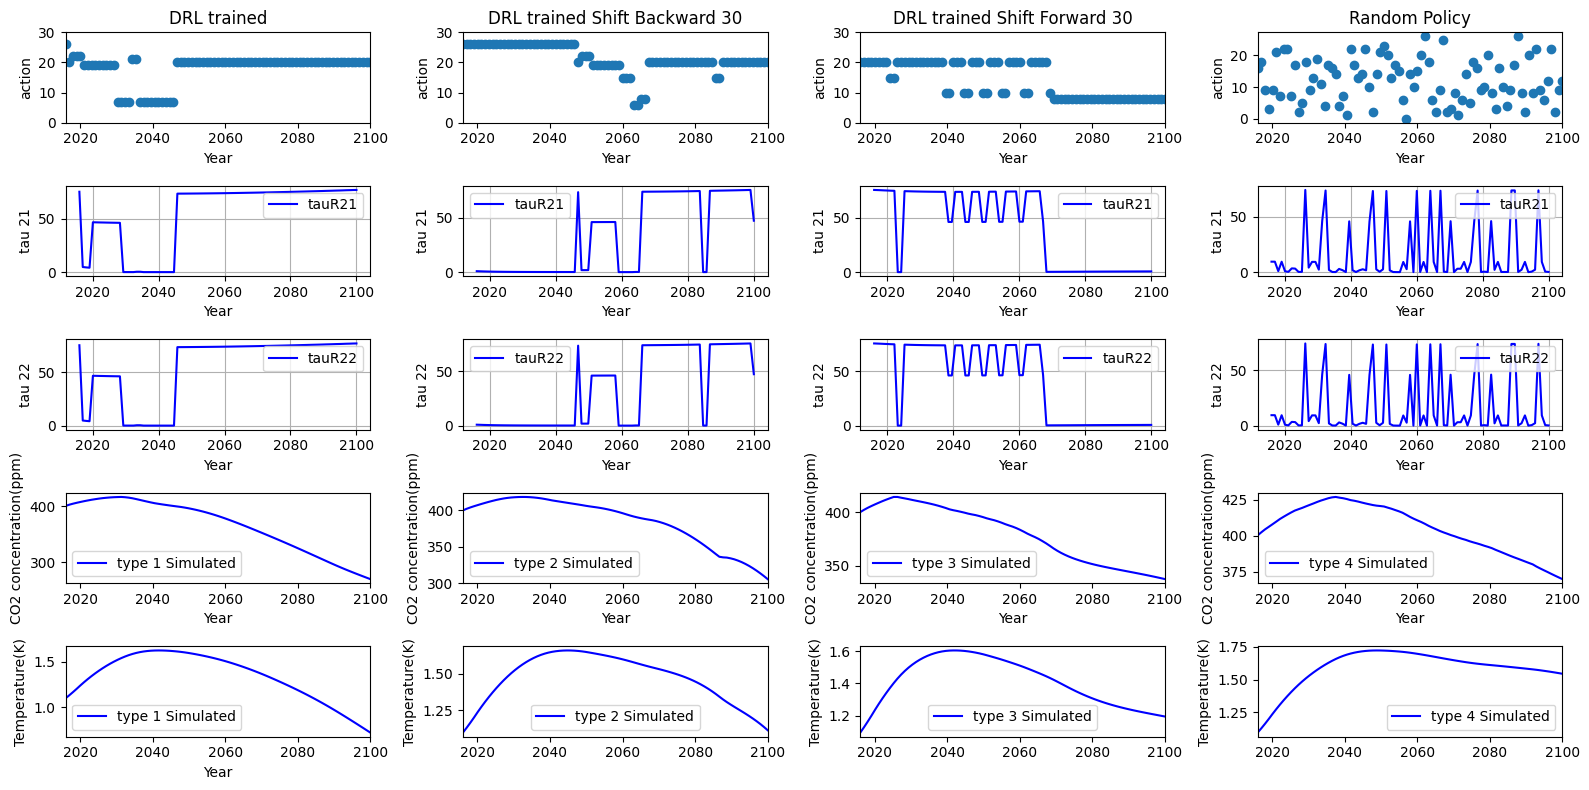

In [ ]:
# 绘制不同动作下参数变化对于系统的影响
# 绘制向前30年和向后30年的结果变化

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
import matplotlib.pyplot as plt

years = np.linspace(2016, 2100, 83)
custom_reward_type = "distance_with_normalized_over"
env = IEMEnv(reward_type=custom_reward_type)

# 增加基准：iseec default 1.58 action=13 默认对比数据
df_83_baseline1 = pd.read_excel(f"data\compare_data\default_action13\episode_0_results_20250720_185238.xlsx")
df_251_baseline1 = pd.read_excel(f"data\compare_data\default_action13\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_fixed_action13.xlsx")

# 读取 drl 正常数据
df_83_type1 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\default_model_predict_dqn_distance_over\episode_0_results_20250720_185019.xlsx")
df_251_type1 = pd.read_excel(r"data\compare_data\special_time_windows_predict_action_roll\default_model_predict_dqn_distance_over\distance_with_normalized_over_v5_DQN_distance.xlsx")

# 读取向后30年数据
df_83_type2 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Backward_30\episode_0_results_20250718_175130.xlsx")
df_251_type2 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Backward_30\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_Shift_Backward_30.xlsx")

# 读取向前30年数据
df_83_type3 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Forward_30\episode_0_results_20250718_174931.xlsx")
df_251_type3 = pd.read_excel(f"data\compare_data\special_time_windows_predict_action_roll\Shift_Forward_30\iseec_ssp5_MIT_data_diy_distance_with_normalized_over_exp404_Shift_Forward_30.xlsx")

# 读取没有经过训练的 agent 
df_83_type4 = pd.read_excel(rf"data\compare_data\special_time_windows_predict_action_roll\random_policy_proper_range\episode_0_results_20250718_165348.xlsx")
df_251_type4 = pd.read_excel(rf"data\compare_data\special_time_windows_predict_action_roll\random_policy_proper_range\iseec_ssp5_MIT_data_diy_weight_three_obj_random_policy.xlsx")

# 阅读变量
action_total_type1 = df_83_type1['action_0']
action_total_type2 = df_83_type2['action_0']
action_total_type3 = df_83_type3['action_0']
action_total_type4 = df_83_type4['action_0']

tauR21_type1 = df_251_type1['taoR21']
tauR21_type2 = df_251_type2['taoR21']
tauR21_type3 = df_251_type3['taoR21']
tauR21_type4 = df_251_type4['taoR21']

tauR22_type1 = df_251_type1['taoR22']
tauR22_type2 = df_251_type2['taoR22']
tauR22_type3 = df_251_type3['taoR22']
tauR22_type4 = df_251_type4['taoR22']

C_a_type1 = df_83_type1['C_a']
C_a_type2 = df_83_type2['C_a']
C_a_type3 = df_83_type3['C_a']
C_a_type4 = df_83_type4['C_a']

T_a_type1 = df_83_type1['T_a']
T_a_type2 = df_83_type2['T_a']
T_a_type3 = df_83_type3['T_a']
T_a_type4 = df_83_type4['T_a']


# 开始绘制
fig, axes = plt.subplots(5, 4, figsize=(16, 8))

# 统一的x轴
xlim = (2016, 2100)

ax1 = axes[0, 0]
ax1.scatter(years, action_total_type1)
ax1.set_xlabel('Year')
ax1.set_ylabel('action')
ax1.set_title('DRL trained')
ax1.set_ylim(0, 30)
ax1.set_xlim(xlim)

ax2 = axes[0, 1]
ax2.scatter(years, action_total_type2)
ax2.set_xlabel('Year')
ax2.set_ylabel('action')
ax2.set_title('DRL trained Shift Backward 30')
ax2.set_ylim(0, 30)
ax2.set_xlim(xlim)

ax3 = axes[0, 2]
ax3.scatter(years, action_total_type3)
ax3.set_xlabel('Year')
ax3.set_ylabel('action')
ax3.set_title('DRL trained Shift Forward 30')
ax3.set_ylim(0, 30)
ax3.set_xlim(xlim)

ax4 = axes[0, 3]
ax4.scatter(years, action_total_type4)
ax4.set_xlabel('Year')
ax4.set_ylabel('action')
ax4.set_title('Random Policy')
ax4.set_xlim(xlim)

ax5 = axes[1, 0]
ax5.plot(years, tauR21_type1[-83:], label='tauR21', color='blue')
ax5.set_xlabel('Year')
ax5.set_ylabel('tau 21')
ax5.legend()
ax5.grid(True)

ax6 = axes[1, 1]
ax6.plot(years, tauR21_type2[-83:], label='tauR21', color='blue')
ax6.set_xlabel('Year')
ax6.set_ylabel('tau 21')
ax6.legend()
ax6.grid(True)

ax7 = axes[1, 2]
ax7.plot(years, tauR21_type3[-83:], label='tauR21', color='blue')
ax7.set_xlabel('Year')
ax7.set_ylabel('tau 21')
ax7.legend()
ax7.grid(True)

ax8 = axes[1, 3]
ax8.plot(years, tauR21_type4[-83:], label='tauR21', color='blue')
ax8.set_xlabel('Year')
ax8.set_ylabel('tau 21')
ax8.legend()
ax8.grid(True)

ax9 = axes[2, 0]
ax9.plot(years, tauR22_type1[-83:], label='tauR22', color='blue')
ax9.set_xlabel('Year')
ax9.set_ylabel('tau 22')
ax9.legend()
ax9.grid(True)

ax10 = axes[2, 1]
ax10.plot(years, tauR22_type2[-83:], label='tauR22', color='blue')
ax10.set_xlabel('Year')
ax10.set_ylabel('tau 22')
ax10.legend()
ax10.grid(True)

ax11 = axes[2, 2]
ax11.plot(years, tauR22_type3[-83:], label='tauR22', color='blue')
ax11.set_xlabel('Year')
ax11.set_ylabel('tau 22')
ax11.legend()
ax11.grid(True)

ax12 = axes[2, 3]
ax12.plot(years, tauR22_type4[-83:], label='tauR22', color='blue')
ax12.set_xlabel('Year')
ax12.set_ylabel('tau 22')
ax12.legend()
ax12.grid(True)

ax13 = axes[3, 0]
ax13.plot(years, C_a_type1 * env.rho_a, label='type 1 Simulated', color='blue')
ax13.set_ylabel("CO2 concentration(ppm)")
ax13.set_xlabel('Year')
ax13.set_xlim(xlim)
ax13.legend()

ax14 = axes[3, 1]
ax14.plot(years, C_a_type2 * env.rho_a, label='type 2 Simulated', color='blue')
ax14.set_ylabel("CO2 concentration(ppm)")
ax14.set_xlabel('Year')
ax14.set_xlim(xlim)
ax14.legend()

ax15 = axes[3, 2]
ax15.plot(years, C_a_type3 * env.rho_a, label='type 3 Simulated', color='blue')
ax15.set_ylabel("CO2 concentration(ppm)")
ax15.set_xlabel('Year')
ax15.set_xlim(xlim)
ax15.legend()

ax16 = axes[3, 3]
ax16.plot(years, C_a_type4 * env.rho_a, label='type 4 Simulated', color='blue')
ax16.set_ylabel("CO2 concentration(ppm)")
ax16.set_xlabel('Year')
ax16.set_xlim(xlim)
ax16.legend()

ax17 = axes[4, 0]
ax17.plot(years, T_a_type1, label='type 1 Simulated', color='blue')
ax17.set_ylabel("Temperature(K)")
ax17.set_xlabel('Year')
ax17.set_xlim(xlim)
ax17.legend()

ax18 = axes[4, 1]
ax18.plot(years, T_a_type2, label='type 2 Simulated', color='blue')
ax18.set_ylabel("Temperature(K)")
ax18.set_xlim(xlim)
ax18.legend()

ax19 = axes[4, 2]
ax19.plot(years, T_a_type3, label='type 3 Simulated', color='blue')
ax19.set_ylabel("Temperature(K)")
ax19.set_xlim(xlim)
ax19.legend()

ax20 = axes[4, 3]
ax20.plot(years, T_a_type4, label='type 4 Simulated', color='blue')
ax20.set_ylabel("Temperature(K)")
ax20.set_xlim(xlim)
ax20.legend()

plt.tight_layout()
plt.show()


### 超参数的试验图

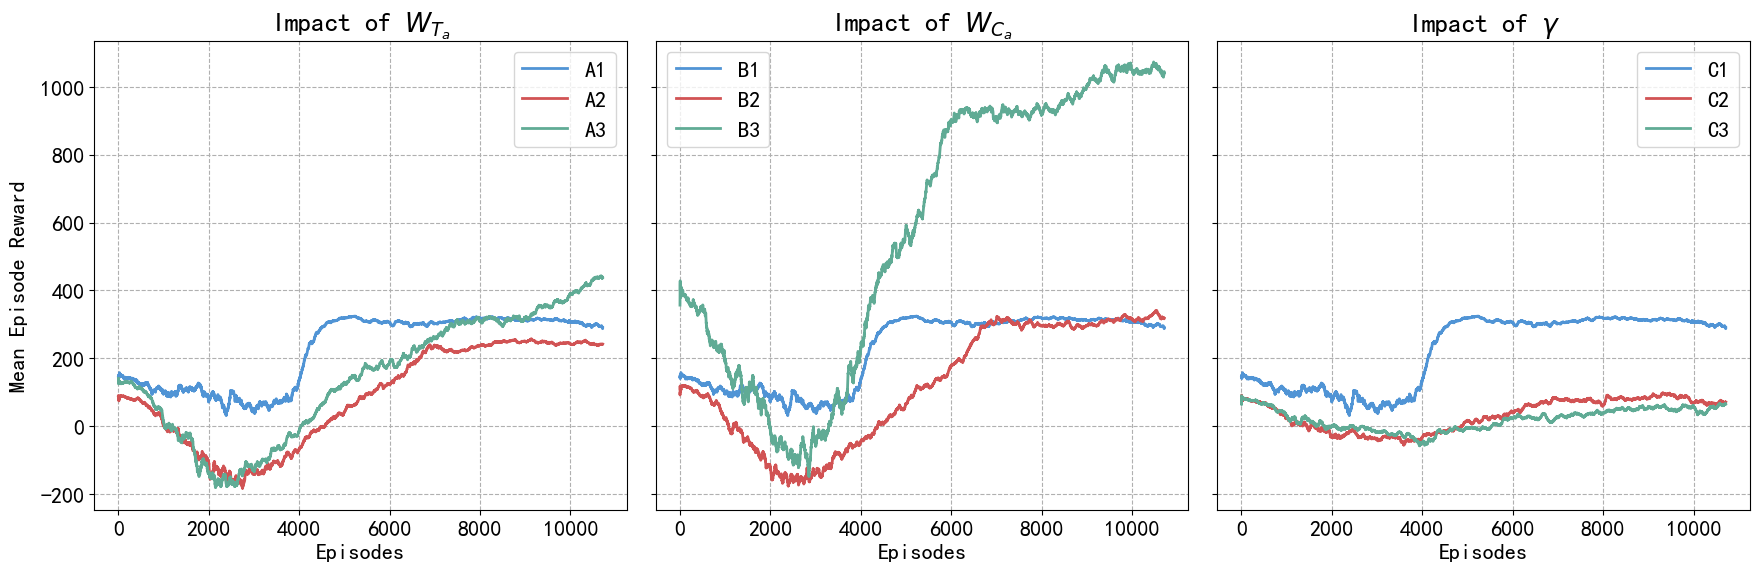

In [64]:
import os
import json
import matplotlib.pyplot as plt

# 读取数据
data_paths = {
    'A1': r"data\compare_data\250724 V1 weight_three_obj_over\progress.json",
    'A2': r"data\compare_data\250818 v3 same weight_weight_Ta_10\progress.json",
    'A3': r"data\compare_data\250818 v3 same weight_weight_Ta_50\progress.json",
    'B1': r"data\compare_data\250724 V1 weight_three_obj_over\progress.json", # 注意B1和A1路径相同
    'B2': r"data\compare_data\250818 v3 same weights_Ca_10\progress.json",
    'B3': r"data\compare_data\250818 v3 same weights_Ca_50\progress.json",
    'C1': r"data\compare_data\250724 V1 weight_three_obj_over\progress.json", # 注意C1和A1路径相同
    'C2': r"data\compare_data\250818 v3 same weights_gamma 0.90\progress.json",
    'C3': r"data\compare_data\250818 v3 same weights_gamma 0.85\progress.json",
}

plot_data = {}
for label, path in data_paths.items():
    ep_rew_mean = []
    episodes = []
    try:
        with open(os.path.join(path), "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    data = json.loads(line)
                    if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                        ep_rew_mean.append(data["rollout/ep_rew_mean"])
                        episodes.append(data["time/episodes"])
    except FileNotFoundError:
        print(f"警告：文件未找到 {path}，跳过此数据点。")
    
    plot_data[label] = {
        'ep_rew_mean': ep_rew_mean,
        'episodes': episodes
    }

# 绘制 Reward
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True) # 增加figsize并共享y轴
plt.rcParams.update({'font.size': 16})
colors = {
    'A1': '#5094D5', 'A2': '#d15354', 'A3': '#60ab95',
    'B1': '#5094D5', 'B2': '#d15354', 'B3': '#60ab95',
    'C1': '#5094D5', 'C2': '#d15354', 'C3': '#60ab95',
}

# 第一列：Ta 权重变化
axes[0].plot(plot_data['A1']['episodes'], plot_data['A1']['ep_rew_mean'], label="A1", color=colors['A1'], linewidth=2)
axes[0].plot(plot_data['A2']['episodes'], plot_data['A2']['ep_rew_mean'], label="A2", color=colors['A2'], linewidth=2)
axes[0].plot(plot_data['A3']['episodes'], plot_data['A3']['ep_rew_mean'], label="A3", color=colors['A3'], linewidth=2)
axes[0].set_xlabel("Episodes")
axes[0].set_title("Impact of $W_{T_a}$")
axes[0].legend()
axes[0].grid(True, linestyle='--')

# 第二列：Ca 权重变化
axes[1].plot(plot_data['B1']['episodes'], plot_data['B1']['ep_rew_mean'], label="B1", color=colors['B1'], linewidth=2)
axes[1].plot(plot_data['B2']['episodes'], plot_data['B2']['ep_rew_mean'], label="B2", color=colors['B2'], linewidth=2)
axes[1].plot(plot_data['B3']['episodes'], plot_data['B3']['ep_rew_mean'], label="B3", color=colors['B3'], linewidth=2)
axes[1].set_xlabel("Episodes")
axes[1].set_title("Impact of $W_{C_a}$")
axes[1].legend()
axes[1].grid(True, linestyle='--')

# 第三列：Gamma 变化
axes[2].plot(plot_data['C1']['episodes'], plot_data['C1']['ep_rew_mean'], label="C1", color=colors['C1'], linewidth=2)
axes[2].plot(plot_data['C2']['episodes'], plot_data['C2']['ep_rew_mean'], label="C2", color=colors['C2'], linewidth=2)
axes[2].plot(plot_data['C3']['episodes'], plot_data['C3']['ep_rew_mean'], label="C3", color=colors['C3'], linewidth=2)
axes[2].set_xlabel("Episodes")
axes[2].set_title('Impact of $\gamma$')
axes[2].legend()
axes[2].grid(True, linestyle='--')

# 添加统一的Y轴标签和总标题
fig.supylabel("Mean Episode Reward", fontsize=16)
# plt.suptitle("Average Reward Convergence Across Different Hyperparameters", fontsize=18, y=1.02)

plt.tight_layout()
plt.show()


[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

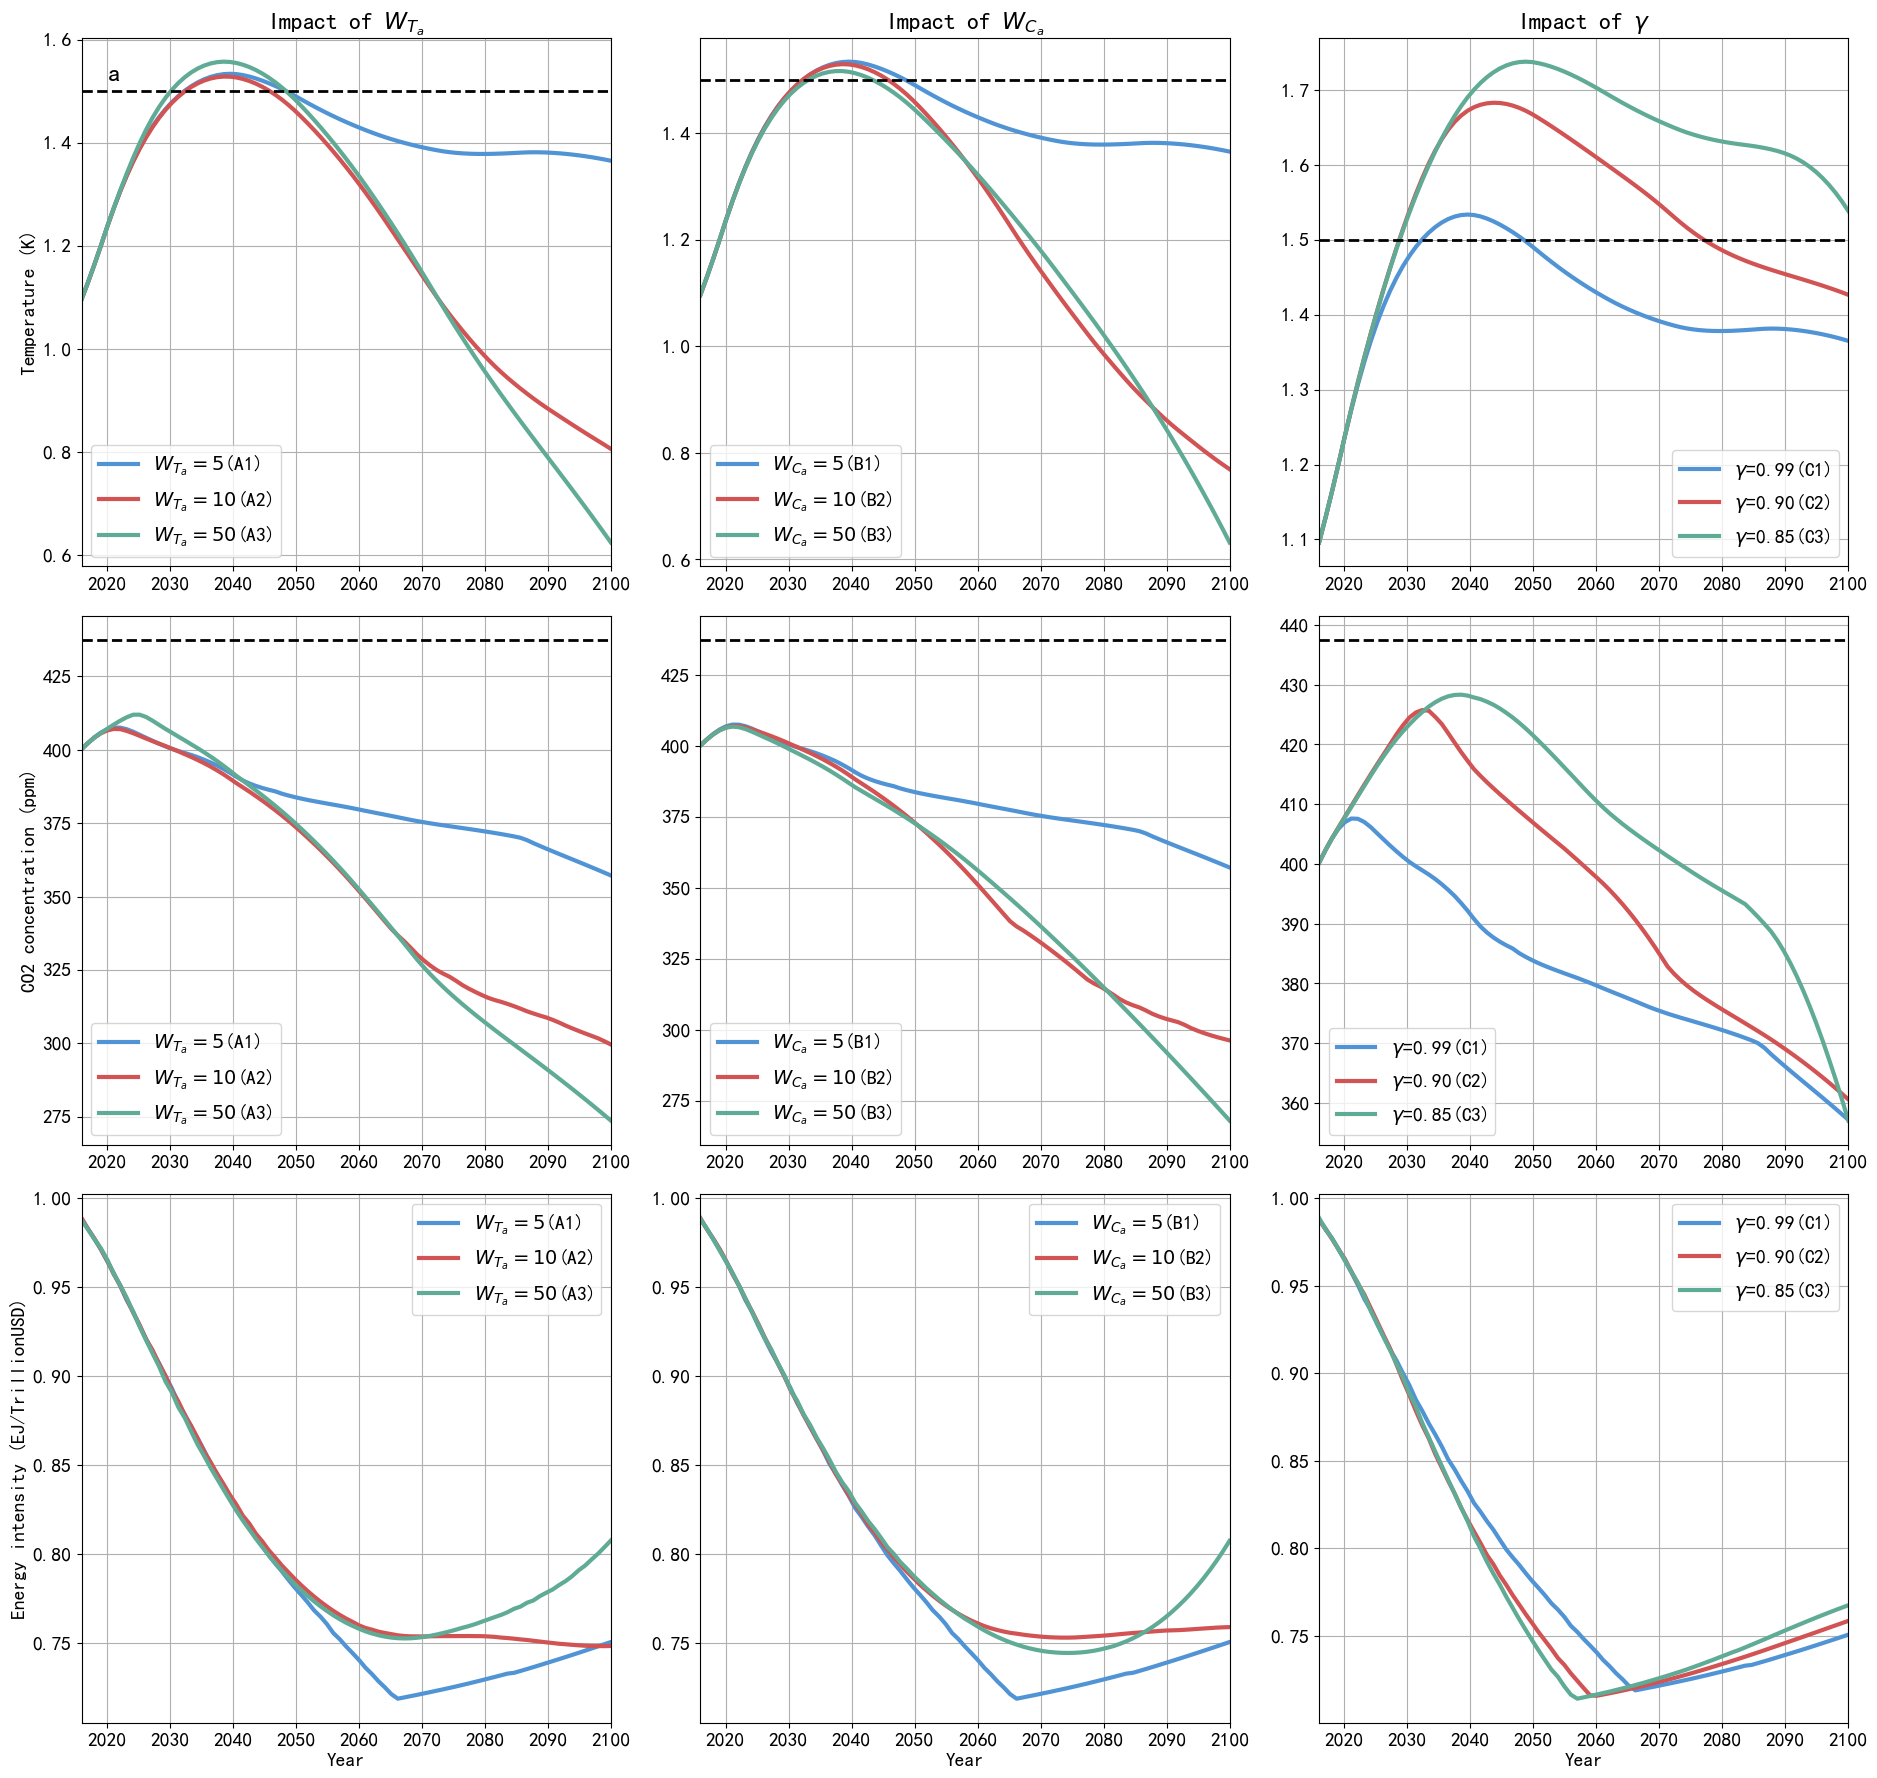

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions import IEMEnv
sys.path.append(os.path.abspath('src'))
# from src.envs.iseec_lx_v5_pomdp_without_masking_all_actions_re import IEMEnv

custom_reward_type = "weight_three_obj_over_same"
env = IEMEnv(reward_type=custom_reward_type)

years = np.linspace(2016, 2100, 83)

# 加载所有实验数据
# Gamma 变动数据
df_83_gamma_0_99 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\episode_0_results_20250818_103558.xlsx")
df_251_gamma_0_99 = pd.read_excel(rf"data\compare_data\250818 v3 same weights 55520 0.99\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

df_83_gamma_0_90 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_gamma 0.90\episode_0_results_20250818_102553.xlsx")
df_251_gamma_0_90 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_gamma 0.90\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

df_83_gamma_0_85 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_gamma 0.85\episode_0_results_20250818_102930.xlsx")
df_251_gamma_0_85 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_gamma 0.85\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

# Ta 权重变动数据
df_83_ta_weight_5 = df_83_gamma_0_99
df_251_ta_weight_5 = df_251_gamma_0_99

df_83_ta_weight_10 = pd.read_excel(rf"data\compare_data\250818 v3 same weight_weight_Ta_10\episode_0_results_20250818_112112.xlsx")
df_251_ta_weight_10 = pd.read_excel(rf"data\compare_data\250818 v3 same weight_weight_Ta_10\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

df_83_ta_weight_50 = pd.read_excel(rf"data\compare_data\250818 v3 same weight_weight_Ta_50\episode_0_results_20250818_112258.xlsx")
df_251_ta_weight_50 = pd.read_excel(rf"data\compare_data\250818 v3 same weight_weight_Ta_50\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

# Ca 权重变动数据
df_83_ca_weight_5 = df_83_gamma_0_99
df_251_ca_weight_5 = df_251_gamma_0_99

df_83_ca_weight_10 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_Ca_10\episode_0_results_20250818_150349.xlsx")
df_251_ca_weight_10 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_Ca_10\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")

df_83_ca_weight_50 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_Ca_50\episode_0_results_20250818_150620.xlsx")
df_251_ca_weight_50 = pd.read_excel(rf"data\compare_data\250818 v3 same weights_Ca_50\iseec_ssp5_MIT_data_diy_weight_three_obj_over_same_DQN.xlsx")


# 辅助函数，用于计算 re
def calculate_re(df_251):
    energy_MYadjusted = df_251['energy_MYadjusted18502100_total_plus_B3B_plus_ACE3']
    energy_MYbaseline = pd.read_excel(rf"data\compare_data\250723 v1_default_action13\iseec_ssp5_MIT_data_diy_weight_three_obj_over_fixed_action_13.xlsx")['energy_MYbaseline18502100_total_formulated']
    re = [
        e_adjusted / e_all
        for e_adjusted, e_all in zip(energy_MYadjusted, energy_MYbaseline)
    ][-83:]
    return re

re_gamma_0_99 = calculate_re(df_251_gamma_0_99)
re_gamma_0_90 = calculate_re(df_251_gamma_0_90)
re_gamma_0_85 = calculate_re(df_251_gamma_0_85)

re_ta_weight_5 = calculate_re(df_251_ta_weight_5)
re_ta_weight_10 = calculate_re(df_251_ta_weight_10)
re_ta_weight_50 = calculate_re(df_251_ta_weight_50)

re_ca_weight_5 = calculate_re(df_251_ca_weight_5)
re_ca_weight_10 = calculate_re(df_251_ca_weight_10)
re_ca_weight_50 = calculate_re(df_251_ca_weight_50)


# 绘制 3x3 子图
fig, axs = plt.subplots(3, 3, figsize=(20, 18))
plt.rcParams.update({'font.size': 14})
xlim = (2016, 2100)

# 第一列：Ta 权重变化
# Ta
axs[0, 0].plot(years, df_83_ta_weight_5['T_a'], color='#5094D5', label='$W_{T_a}=5$(A1)', linewidth=3)
axs[0, 0].plot(years, df_83_ta_weight_10['T_a'], color='#d15354', label='$W_{T_a}=10$(A2)', linewidth=3)
axs[0, 0].plot(years, df_83_ta_weight_50['T_a'], color='#60ab95', label='$W_{T_a}=50$(A3)', linewidth=3)
axs[0, 0].axhline(y=1.5, color='black', linestyle='--', linewidth=2)
axs[0, 0].set_ylabel('Temperature (K)')
axs[0, 0].legend()
axs[0, 0].set_title('Impact of $W_{T_a}$')
axs[0, 0].grid(True)
axs[0, 0].set_xlim(xlim)
# axs[0, 0].text(0.05, 0.95, 'a', transform=axs[0, 0].transAxes, fontsize=18, fontweight='bold', va='top')

# Ca
axs[1, 0].plot(years, df_83_ta_weight_5['C_a'] * env.rho_a, color='#5094D5', label='$W_{T_a}=5$(A1)', linewidth=3)
axs[1, 0].plot(years, df_83_ta_weight_10['C_a'] * env.rho_a, color='#d15354', label='$W_{T_a}=10$(A2)', linewidth=3)
axs[1, 0].plot(years, df_83_ta_weight_50['C_a'] * env.rho_a, color='#60ab95', label='$W_{T_a}=50$(A3)', linewidth=3)
axs[1, 0].axhline(y=945 * env.rho_a, color='black', linestyle='--', linewidth=2)
axs[1, 0].set_ylabel('CO2 concentration (ppm)')
axs[1, 0].legend()
axs[1, 0].grid(True)
axs[1, 0].set_xlim(xlim)

# re
axs[2, 0].plot(years, re_ta_weight_5, color='#5094D5', label='$W_{T_a}=5$(A1)', linewidth=3)
axs[2, 0].plot(years, re_ta_weight_10, color='#d15354', label='$W_{T_a}=10$(A2)', linewidth=3)
axs[2, 0].plot(years, re_ta_weight_50, color='#60ab95', label='$W_{T_a}=50$(A3)', linewidth=3)
axs[2, 0].set_ylabel('Energy intensity (EJ/TrillionUSD)')
axs[2, 0].set_xlabel('Year')
axs[2, 0].legend()
axs[2, 0].grid(True)
axs[2, 0].set_xlim(xlim)


# 第二列：Ca 权重变化
# Ta
axs[0, 1].plot(years, df_83_ca_weight_5['T_a'], color='#5094D5', label='$W_{C_a}=5$(B1)', linewidth=3)
axs[0, 1].plot(years, df_83_ca_weight_10['T_a'], color='#d15354', label='$W_{C_a}=10$(B2)', linewidth=3)
axs[0, 1].plot(years, df_83_ca_weight_50['T_a'], color='#60ab95', label='$W_{C_a}=50$(B3)', linewidth=3)
axs[0, 1].axhline(y=1.5, color='black', linestyle='--', linewidth=2)
axs[0, 1].legend()
axs[0, 1].set_title('Impact of $W_{C_a}$')
axs[0, 1].grid(True)
axs[0, 1].set_xlim(xlim)

# Ca
axs[1, 1].plot(years, df_83_ca_weight_5['C_a'] * env.rho_a, color='#5094D5', label='$W_{C_a}=5$(B1)', linewidth=3)
axs[1, 1].plot(years, df_83_ca_weight_10['C_a'] * env.rho_a, color='#d15354', label='$W_{C_a}=10$(B2)', linewidth=3)
axs[1, 1].plot(years, df_83_ca_weight_50['C_a'] * env.rho_a, color='#60ab95', label='$W_{C_a}=50$(B3)', linewidth=3)
axs[1, 1].axhline(y=945 * env.rho_a, color='black', linestyle='--', linewidth=2)
axs[1, 1].legend()
axs[1, 1].grid(True)
axs[1, 1].set_xlim(xlim)

# re
axs[2, 1].plot(years, re_ca_weight_5, color='#5094D5', label='$W_{C_a}=5$(B1)', linewidth=3)
axs[2, 1].plot(years, re_ca_weight_10, color='#d15354', label='$W_{C_a}=10$(B2)', linewidth=3)
axs[2, 1].plot(years, re_ca_weight_50, color='#60ab95', label='$W_{C_a}=50$(B3)', linewidth=3)
axs[2, 1].set_xlabel('Year')
axs[2, 1].legend()
axs[2, 1].grid(True)
axs[2, 1].set_xlim(xlim)


# 第三列：Gamma 变化
# Ta
axs[0, 2].plot(years, df_83_gamma_0_99['T_a'], color='#5094D5', label='$\gamma$=0.99(C1)', linewidth=3)
axs[0, 2].plot(years, df_83_gamma_0_90['T_a'], color='#d15354', label='$\gamma$=0.90(C2)', linewidth=3)
axs[0, 2].plot(years, df_83_gamma_0_85['T_a'], color='#60ab95', label='$\gamma$=0.85(C3)', linewidth=3)
axs[0, 2].axhline(y=1.5, color='black', linestyle='--', linewidth=2)
axs[0, 2].legend()
axs[0, 2].set_title('Impact of $\gamma$')
axs[0, 2].grid(True)
axs[0, 2].set_xlim(xlim)

# Ca
axs[1, 2].plot(years, df_83_gamma_0_99['C_a'] * env.rho_a, color='#5094D5', label='$\gamma$=0.99(C1)', linewidth=3)
axs[1, 2].plot(years, df_83_gamma_0_90['C_a'] * env.rho_a, color='#d15354', label='$\gamma$=0.90(C2)', linewidth=3)
axs[1, 2].plot(years, df_83_gamma_0_85['C_a'] * env.rho_a, color='#60ab95', label='$\gamma$=0.85(C3)', linewidth=3)
axs[1, 2].axhline(y=945 * env.rho_a, color='black', linestyle='--', linewidth=2)
axs[1, 2].legend()
axs[1, 2].grid(True)
axs[1, 2].set_xlim(xlim)

# re
axs[2, 2].plot(years, re_gamma_0_99, color='#5094D5', label='$\gamma$=0.99(C1)', linewidth=3)
axs[2, 2].plot(years, re_gamma_0_90, color='#d15354', label='$\gamma$=0.90(C2)', linewidth=3)
axs[2, 2].plot(years, re_gamma_0_85, color='#60ab95', label='$\gamma$=0.85(C3)', linewidth=3)
axs[2, 2].set_xlabel('Year')
axs[2, 2].legend()
axs[2, 2].grid(True)
axs[2, 2].set_xlim(xlim)

# 统一 Y 轴标签
# fig.text(0.04, 0.77, 'Temperature (K)', ha='center', va='center', rotation='vertical', fontsize=16)
# fig.text(0.04, 0.5, 'CO2 concentration (ppm)', ha='center', va='center', rotation='vertical', fontsize=16)
# fig.text(0.04, 0.23, 'Energy intensity (EJ/TrillionUSD)', ha='center', va='center', rotation='vertical', fontsize=16)

plt.tight_layout(rect=[0.05, 0, 1, 1])

# 保存图表
plt.savefig('combined_plot.png')
plt.show()
